<a href="https://colab.research.google.com/github/Etuarda/capacitacao-tecnica-em-IA--FDTE_USP/blob/main/EduardaAMQ_pynb_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip -q install minisom scipy scikit-learn matplotlib tqdm

import os, zipfile, sys, math, random, subprocess
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset, ConcatDataset

from torchvision import datasets, transforms

from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

from scipy import stats
from scipy.linalg import sqrtm

# 1) Eu extraio o ZIP na raiz do /content
ZIP_PATH = "/content/atividade19_12_revisada.zip"
ROOT = Path("/content")
OUT = ROOT / "resultados"
OUT.mkdir(exist_ok=True)

if Path(ZIP_PATH).exists():
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(str(ROOT))
else:
    print(f"[ALERTA] ZIP não encontrado em: {ZIP_PATH}")

# 2) seleciono GPU se existir (GAN/AE ficam inviáveis no CPU).
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("[OK] device =", DEVICE)

# 3) fixo seeds para reduzir variação entre execuções.
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

# 4) carrego MNIST com separação fixa (treino real / teste real).
transform = transforms.ToTensor()
train_ds_raw = datasets.MNIST(root="/content/data", train=True, download=True, transform=transform)
test_ds_raw  = datasets.MNIST(root="/content/data", train=False, download=True, transform=transform)

# 5) Eu padronizo os datasets para nunca voltar item inconsistente.
def _is_image_like(obj):
    return isinstance(obj, torch.Tensor) and obj.ndim >= 2

class SafeXYDataset(Dataset):
    """
    Eu uso esse wrapper para garantir que SEMPRE sai (x_tensor, y_long),
    mesmo que a amostra venha invertida (y, x) ou com y int vs tensor.
    """
    def __init__(self, base_ds):
        self.base = base_ds

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        a, b = self.base[idx]

        # Se vier invertido, eu corrijo pelo tipo/shape.
        if _is_image_like(a) and not _is_image_like(b):
            x, y = a, b
        elif _is_image_like(b) and not _is_image_like(a):
            x, y = b, a
        else:
            # Caso extremo: eu tento assumir a como imagem.
            x, y = a, b

        if not isinstance(x, torch.Tensor):
            x = torch.tensor(x)

        # Eu garanto float e formato [1,28,28] quando possível.
        x = x.float()
        if x.ndim == 2:
            x = x.unsqueeze(0)
        if x.ndim == 1 and x.numel() == 28*28:
            x = x.view(1, 28, 28)

        # Eu normalizo para [0,1] se vier em [-1,1].
        if x.min() < 0:
            x = (x + 1.0) / 2.0
        x = torch.clamp(x, 0.0, 1.0)

        if isinstance(y, torch.Tensor):
            y = int(y.item())
        y = torch.tensor(y, dtype=torch.long)

        return x, y

train_ds = SafeXYDataset(train_ds_raw)
test_ds  = SafeXYDataset(test_ds_raw)

# 6) Eu uso num_workers=0 para evitar o erro "can only test a child process" no Colab.
def make_loader(ds, batch=128, shuffle=True):
    return DataLoader(
        ds,
        batch_size=batch,
        shuffle=shuffle,
        num_workers=0,             # eu mantenho 0 no Colab
        pin_memory=torch.cuda.is_available()
    )

train_loader_real = make_loader(train_ds, batch=128, shuffle=True)
test_loader_real  = make_loader(test_ds,  batch=128, shuffle=False)

# 7) Avaliação centralizada (acurácia + matriz de confusão).
@torch.no_grad()
def eval_model(model, loader, device=DEVICE):
    model.eval()
    ys, ps = [], []
    for x, y in loader:
        x = x.to(device)
        y = y.to(device)
        logits = model(x)
        pred = torch.argmax(logits, dim=1)
        ys.append(y.detach().cpu().numpy())
        ps.append(pred.detach().cpu().numpy())
    y_true = np.concatenate(ys)
    y_pred = np.concatenate(ps)
    acc = accuracy_score(y_true, y_pred)
    return acc, y_true, y_pred

def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm)
    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(ax=ax, values_format="d", colorbar=False)
    ax.set_title(title)
    plt.show()

# 8) Eu implemento um FID simples usando features 2D (evita cov em 3D/4D).
def _cov_2d(x_2d: np.ndarray):
    # x: [N, D]
    return np.cov(x_2d, rowvar=False)

def compute_fid(feats_real: np.ndarray, feats_fake: np.ndarray, eps=1e-6) -> float:
    """
    Eu calculo o FID em cima de features 2D: [N,D].
    """
    feats_real = np.asarray(feats_real, dtype=np.float64)
    feats_fake = np.asarray(feats_fake, dtype=np.float64)

    mu1, mu2 = feats_real.mean(axis=0), feats_fake.mean(axis=0)
    s1, s2 = _cov_2d(feats_real), _cov_2d(feats_fake)

    # Eu adiciono eps para estabilizar.
    s1 = s1 + np.eye(s1.shape[0]) * eps
    s2 = s2 + np.eye(s2.shape[0]) * eps

    covmean = sqrtm(s1 @ s2)
    if np.iscomplexobj(covmean):
        covmean = covmean.real

    diff = mu1 - mu2
    fid = diff.dot(diff) + np.trace(s1 + s2 - 2.0 * covmean)
    return float(fid)

@torch.no_grad()
def extract_features(model, loader, device=DEVICE):
    """
    Eu extraio features da penúltima camada via hook (sempre 2D no final).
    """
    model.eval()
    feats = []

    # Eu tento pegar uma camada "fc" comum; se não existir, eu hooko o último Linear.
    target_layer = None
    for name, m in model.named_modules():
        if isinstance(m, nn.Linear):
            target_layer = m

    if target_layer is None:
        raise RuntimeError("Não encontrei camada Linear para extrair features.")

    buffer = {"h": None}
    def hook_fn(module, inp, out):
        buffer["h"] = out

    hdl = target_layer.register_forward_hook(hook_fn)

    for x, y in loader:
        x = x.to(device)
        _ = model(x)
        h = buffer["h"]
        if h is None:
            raise RuntimeError("Hook não capturou features.")
        h = h.detach().cpu()
        if h.ndim > 2:
            h = h.view(h.size(0), -1)
        feats.append(h.numpy())

    hdl.remove()
    feats = np.concatenate(feats, axis=0)  # [N, D]
    return feats


[OK] device = cuda



EXP1 — CNN baseline | 10 execuções | teste só com dados reais
[CNN] Epoch 1/10 | Loss: 0.2392
[CNN] Epoch 2/10 | Loss: 0.0602
[CNN] Epoch 3/10 | Loss: 0.0414
[CNN] Epoch 4/10 | Loss: 0.0312
[CNN] Epoch 5/10 | Loss: 0.0251
[CNN] Epoch 6/10 | Loss: 0.0194
[CNN] Epoch 7/10 | Loss: 0.0154
[CNN] Epoch 8/10 | Loss: 0.0139
[CNN] Epoch 9/10 | Loss: 0.0100
[CNN] Epoch 10/10 | Loss: 0.0093
[EXP1] run=01 acc=0.9899
[CNN] Epoch 1/10 | Loss: 0.2236
[CNN] Epoch 2/10 | Loss: 0.0559
[CNN] Epoch 3/10 | Loss: 0.0369
[CNN] Epoch 4/10 | Loss: 0.0293
[CNN] Epoch 5/10 | Loss: 0.0225
[CNN] Epoch 6/10 | Loss: 0.0182
[CNN] Epoch 7/10 | Loss: 0.0141
[CNN] Epoch 8/10 | Loss: 0.0121
[CNN] Epoch 9/10 | Loss: 0.0108
[CNN] Epoch 10/10 | Loss: 0.0076
[EXP1] run=02 acc=0.9909
[CNN] Epoch 1/10 | Loss: 0.2543
[CNN] Epoch 2/10 | Loss: 0.0627
[CNN] Epoch 3/10 | Loss: 0.0448
[CNN] Epoch 4/10 | Loss: 0.0334
[CNN] Epoch 5/10 | Loss: 0.0278
[CNN] Epoch 6/10 | Loss: 0.0219
[CNN] Epoch 7/10 | Loss: 0.0185
[CNN] Epoch 8/10 | Lo

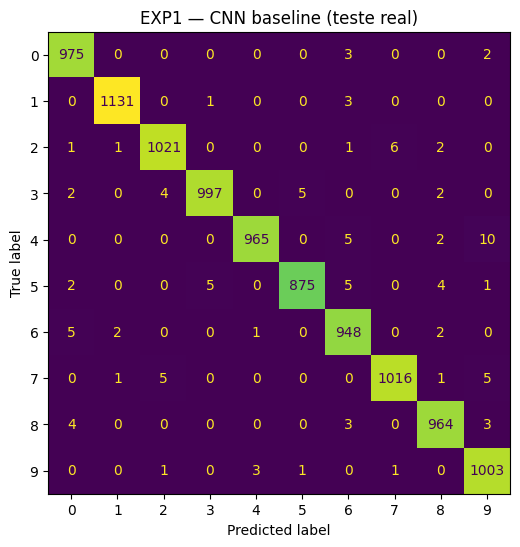

In [ ]:

# EXPERIMENTO 1 — CNN baseline (10 execuções + estatística)

# Arquitetura: 2 conv (32/64) + ReLU + MaxPool + FC + Softmax
# Parâmetros: batch=128, epochs=10, Adam lr=1e-3
# Eu rodo 10x porque o enunciado recomenda e isso sustenta análise estatística.

class CNNBaseline(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1  = nn.Linear(64 * 7 * 7, 128)
        self.fc2  = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))      # [B,32,14,14]
        x = self.pool(F.relu(self.conv2(x)))      # [B,64,7,7]
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)                           # logits
        return x

def train_cnn(model, loader, epochs=10, lr=1e-3, device=DEVICE):
    model.train()
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    for ep in range(1, epochs+1):
        running = 0.0
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad(set_to_none=True)
            logits = model(x)
            loss = loss_fn(logits, y)
            loss.backward()
            opt.step()
            running += loss.item()
        print(f"[CNN] Epoch {ep}/{epochs} | Loss: {running/len(loader):.4f}")

N_RUNS = 10
rows = []

print("\n" + "="*80)
print("EXP1 — CNN baseline | 10 execuções | teste só com dados reais")
print("="*80)

last_y_true, last_y_pred = None, None

for run in range(1, N_RUNS+1):
    set_seed(1000 + run)
    model = CNNBaseline().to(DEVICE)
    train_cnn(model, train_loader_real, epochs=10, lr=1e-3)

    acc, y_true, y_pred = eval_model(model, test_loader_real)
    rows.append({"run": run, "test_acc": acc})
    last_y_true, last_y_pred = y_true, y_pred

    print(f"[EXP1] run={run:02d} acc={acc:.4f}")

df_exp1 = pd.DataFrame(rows)
df_exp1.to_csv(OUT / "exp1_cnn_10runs.csv", index=False)
print("\n[OK] salvo:", OUT / "exp1_cnn_10runs.csv")

accs = df_exp1["test_acc"].values
print("[EXP1] mean/std/min/max:", float(accs.mean()), float(accs.std(ddof=1)), float(accs.min()), float(accs.max()))
print("[EXP1] Shapiro p:", float(stats.shapiro(accs).pvalue))

plot_cm(last_y_true, last_y_pred, "EXP1 — CNN baseline (teste real)")



EXP2 — mlp | z=100, epochs=50, lr=2e-4 | ratios 10/30/50 | teste real
[CNN] Epoch 1/10 | Loss: 0.2374
[CNN] Epoch 2/10 | Loss: 0.0598
[CNN] Epoch 3/10 | Loss: 0.0425
[CNN] Epoch 4/10 | Loss: 0.0318
[CNN] Epoch 5/10 | Loss: 0.0248
[CNN] Epoch 6/10 | Loss: 0.0198
[CNN] Epoch 7/10 | Loss: 0.0165
[CNN] Epoch 8/10 | Loss: 0.0150
[CNN] Epoch 9/10 | Loss: 0.0122
[CNN] Epoch 10/10 | Loss: 0.0087
[cGAN] Epoch 1/50 | D: 0.7080 | G: 2.9909
[cGAN] Epoch 2/50 | D: 0.1823 | G: 5.1097
[cGAN] Epoch 3/50 | D: 0.1950 | G: 5.6335
[cGAN] Epoch 4/50 | D: 0.2272 | G: 5.4040
[cGAN] Epoch 5/50 | D: 0.2284 | G: 5.6010
[cGAN] Epoch 6/50 | D: 0.2703 | G: 5.5407
[cGAN] Epoch 7/50 | D: 0.3443 | G: 5.1869
[cGAN] Epoch 8/50 | D: 0.4068 | G: 5.0013
[cGAN] Epoch 9/50 | D: 0.4274 | G: 4.7516
[cGAN] Epoch 10/50 | D: 0.4309 | G: 4.9519
[cGAN] Epoch 11/50 | D: 0.4033 | G: 4.7153
[cGAN] Epoch 12/50 | D: 0.4562 | G: 4.5702
[cGAN] Epoch 13/50 | D: 0.4588 | G: 4.6266
[cGAN] Epoch 14/50 | D: 0.5063 | G: 4.3407
[cGAN] Epoch 15

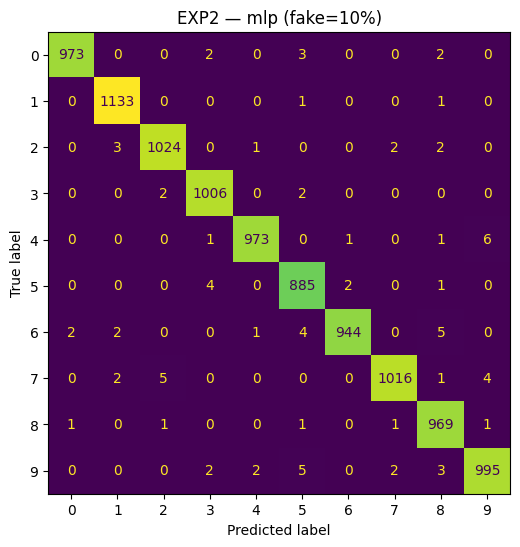

[CNN] Epoch 1/10 | Loss: 0.1992
[CNN] Epoch 2/10 | Loss: 0.0455
[CNN] Epoch 3/10 | Loss: 0.0315
[CNN] Epoch 4/10 | Loss: 0.0230
[CNN] Epoch 5/10 | Loss: 0.0184
[CNN] Epoch 6/10 | Loss: 0.0155
[CNN] Epoch 7/10 | Loss: 0.0119
[CNN] Epoch 8/10 | Loss: 0.0093
[CNN] Epoch 9/10 | Loss: 0.0087
[CNN] Epoch 10/10 | Loss: 0.0076
[EXP2] mlp ratio=0.30 acc=0.9895 FID=618.94


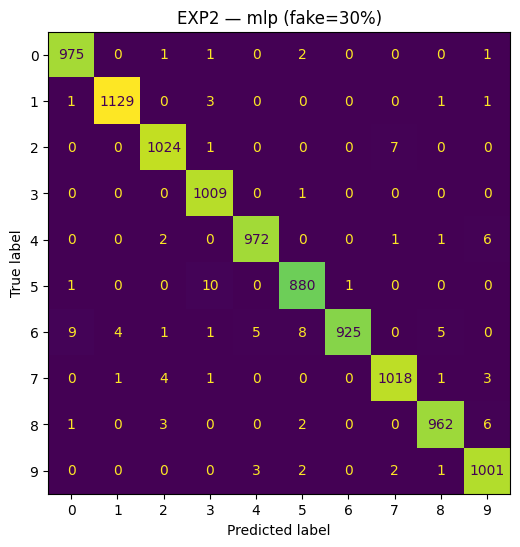

[CNN] Epoch 1/10 | Loss: 0.1892
[CNN] Epoch 2/10 | Loss: 0.0402
[CNN] Epoch 3/10 | Loss: 0.0273
[CNN] Epoch 4/10 | Loss: 0.0212
[CNN] Epoch 5/10 | Loss: 0.0156
[CNN] Epoch 6/10 | Loss: 0.0127
[CNN] Epoch 7/10 | Loss: 0.0102
[CNN] Epoch 8/10 | Loss: 0.0084
[CNN] Epoch 9/10 | Loss: 0.0071
[CNN] Epoch 10/10 | Loss: 0.0061
[EXP2] mlp ratio=0.50 acc=0.9911 FID=618.94


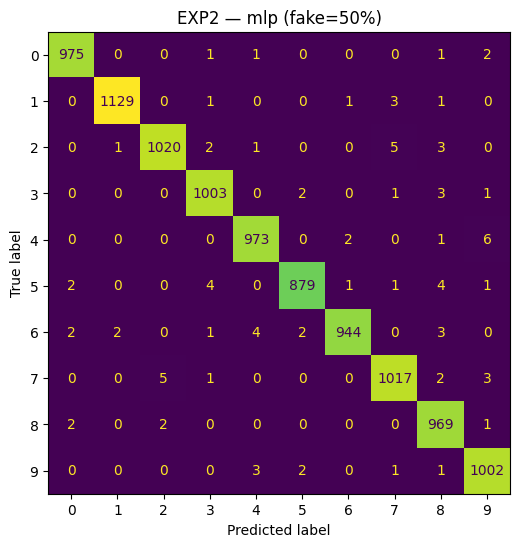

[OK] salvo: /content/resultados/exp2_mlp_ratios.csv

EXP2 — conv | z=100, epochs=50, lr=2e-4 | ratios 10/30/50 | teste real
[CNN] Epoch 1/10 | Loss: 0.2344
[CNN] Epoch 2/10 | Loss: 0.0600
[CNN] Epoch 3/10 | Loss: 0.0435
[CNN] Epoch 4/10 | Loss: 0.0312
[CNN] Epoch 5/10 | Loss: 0.0254
[CNN] Epoch 6/10 | Loss: 0.0199
[CNN] Epoch 7/10 | Loss: 0.0174
[CNN] Epoch 8/10 | Loss: 0.0135
[CNN] Epoch 9/10 | Loss: 0.0105
[CNN] Epoch 10/10 | Loss: 0.0088
[cGAN] Epoch 1/50 | D: 0.5446 | G: 2.7400
[cGAN] Epoch 2/50 | D: 1.1897 | G: 0.8942
[cGAN] Epoch 3/50 | D: 1.1129 | G: 0.9016
[cGAN] Epoch 4/50 | D: 0.9776 | G: 1.0457
[cGAN] Epoch 5/50 | D: 0.8702 | G: 1.1901
[cGAN] Epoch 6/50 | D: 0.8547 | G: 1.2286
[cGAN] Epoch 7/50 | D: 0.7806 | G: 1.3481
[cGAN] Epoch 8/50 | D: 0.7198 | G: 1.4592
[cGAN] Epoch 9/50 | D: 0.6254 | G: 1.6057
[cGAN] Epoch 10/50 | D: 0.5933 | G: 1.7137
[cGAN] Epoch 11/50 | D: 0.5379 | G: 1.8381
[cGAN] Epoch 12/50 | D: 0.4987 | G: 1.9889
[cGAN] Epoch 13/50 | D: 0.4685 | G: 2.0628
[cGAN

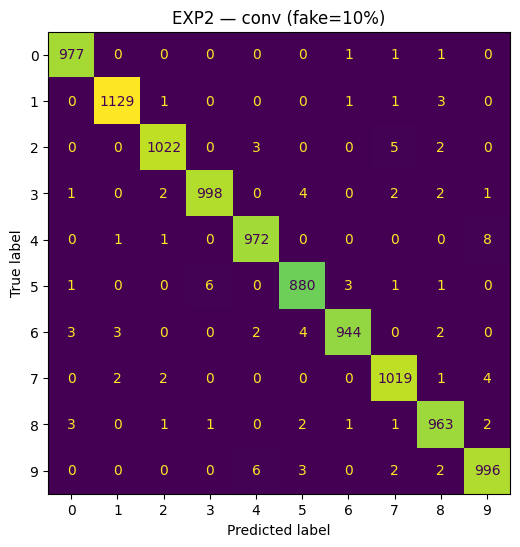

[CNN] Epoch 1/10 | Loss: 0.2088
[CNN] Epoch 2/10 | Loss: 0.0482
[CNN] Epoch 3/10 | Loss: 0.0324
[CNN] Epoch 4/10 | Loss: 0.0241
[CNN] Epoch 5/10 | Loss: 0.0196
[CNN] Epoch 6/10 | Loss: 0.0145
[CNN] Epoch 7/10 | Loss: 0.0126
[CNN] Epoch 8/10 | Loss: 0.0099
[CNN] Epoch 9/10 | Loss: 0.0089
[CNN] Epoch 10/10 | Loss: 0.0076
[EXP2] conv ratio=0.30 acc=0.9904 FID=482.58


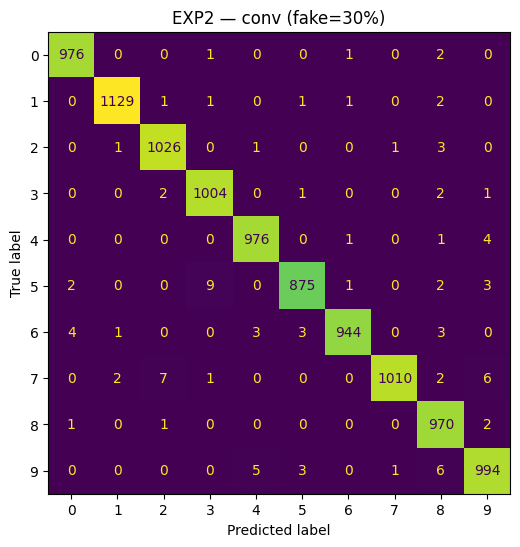

[CNN] Epoch 1/10 | Loss: 0.1858
[CNN] Epoch 2/10 | Loss: 0.0473
[CNN] Epoch 3/10 | Loss: 0.0335
[CNN] Epoch 4/10 | Loss: 0.0242
[CNN] Epoch 5/10 | Loss: 0.0182
[CNN] Epoch 6/10 | Loss: 0.0158
[CNN] Epoch 7/10 | Loss: 0.0116
[CNN] Epoch 8/10 | Loss: 0.0101
[CNN] Epoch 9/10 | Loss: 0.0091
[CNN] Epoch 10/10 | Loss: 0.0076
[EXP2] conv ratio=0.50 acc=0.9895 FID=482.58


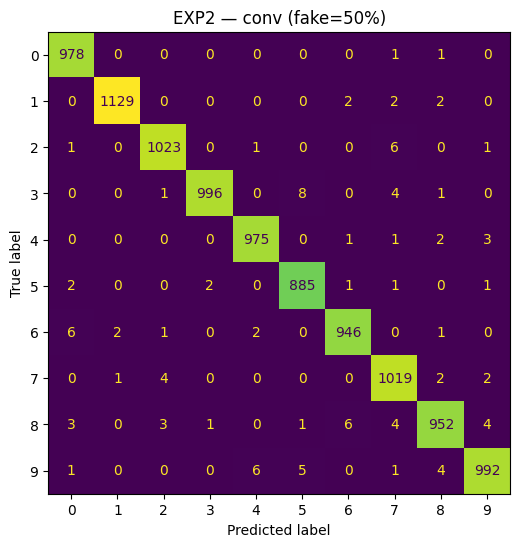

[OK] salvo: /content/resultados/exp2_conv_ratios.csv


In [ ]:

# EXPERIMENTO 2 — cGAN condicional (MLP e Conv) + 10/30/50 + FID

# Protocolo:
# 1) Eu treino a GAN com dados reais
# 2) Eu gero imagens sintéticas por classe
# 3) Eu misturo real+sintético (10%, 30%, 50%)
# 4) Eu treino a CNN do zero
# 5) Eu testo só em real
# 6) Eu comparo com o EXP1

RATIOS = [0.10, 0.30, 0.50]
Z_DIM = 100
GAN_EPOCHS = 50
GAN_LR = 2e-4

# Eu uso one-hot nas labels para GAN MLP.
def one_hot(y, n_classes=10):
    return F.one_hot(y, n_classes).float()

class CGAN_MLP_G(nn.Module):
    def __init__(self, z_dim=100, n_classes=10, img_dim=28*28):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim + n_classes, 256),
            nn.ReLU(True),
            nn.Linear(256, 512),
            nn.ReLU(True),
            nn.Linear(512, img_dim),
            nn.Tanh()
        )

    def forward(self, z, y):
        yoh = one_hot(y)
        x = torch.cat([z, yoh], dim=1)
        out = self.net(x).view(-1, 1, 28, 28)
        return out

class CGAN_MLP_D(nn.Module):
    def __init__(self, n_classes=10, img_dim=28*28):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(img_dim + n_classes, 512),
            nn.LeakyReLU(0.2, True),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, True),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x, y):
        yoh = one_hot(y)
        x = x.view(x.size(0), -1)
        inp = torch.cat([x, yoh], dim=1)
        return self.net(inp)

# Eu uso um cDCGAN simples para a versão conv.
class CGAN_CONV_G(nn.Module):
    def __init__(self, z_dim=100, n_classes=10):
        super().__init__()
        self.embed = nn.Embedding(n_classes, n_classes)
        self.fc = nn.Linear(z_dim + n_classes, 128 * 7 * 7)
        self.deconv = nn.Sequential(
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),  # 14x14
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 1, 4, stride=2, padding=1),    # 28x28
            nn.Tanh()
        )

    def forward(self, z, y):
        yemb = self.embed(y)
        x = torch.cat([z, yemb], dim=1)
        x = self.fc(x).view(-1, 128, 7, 7)
        return self.deconv(x)

class CGAN_CONV_D(nn.Module):
    def __init__(self, n_classes=10):
        super().__init__()
        self.embed = nn.Embedding(n_classes, 28*28)
        self.conv = nn.Sequential(
            nn.Conv2d(2, 64, 4, stride=2, padding=1),   # 14x14
            nn.LeakyReLU(0.2, True),
            nn.Conv2d(64, 128, 4, stride=2, padding=1), # 7x7
            nn.LeakyReLU(0.2, True),
        )
        self.fc = nn.Sequential(
            nn.Linear(128*7*7, 1),
            nn.Sigmoid()
        )

    def forward(self, x, y):
        ymap = self.embed(y).view(-1, 1, 28, 28)
        inp = torch.cat([x, ymap], dim=1)  # eu “condiciono” pela imagem da label
        h = self.conv(inp).view(x.size(0), -1)
        return self.fc(h)

def train_cgan(G, D, loader, epochs=50, z_dim=100, lr=2e-4, device=DEVICE):
    G.train(); D.train()
    optG = torch.optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
    optD = torch.optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))
    bce = nn.BCELoss()

    for ep in range(1, epochs+1):
        loss_d, loss_g = 0.0, 0.0
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            bs = x.size(0)

            # Eu treino o discriminador.
            z = torch.randn(bs, z_dim, device=device)
            fake = G(z, y).detach()

            real_lbl = torch.ones(bs, 1, device=device)
            fake_lbl = torch.zeros(bs, 1, device=device)

            D.zero_grad(set_to_none=True)
            pr = D(x, y)
            pf = D(fake, y)
            d_loss = bce(pr, real_lbl) + bce(pf, fake_lbl)
            d_loss.backward()
            optD.step()

            # Eu treino o gerador.
            z = torch.randn(bs, z_dim, device=device)
            G.zero_grad(set_to_none=True)
            gen = G(z, y)
            pg = D(gen, y)
            g_loss = bce(pg, real_lbl)
            g_loss.backward()
            optG.step()

            loss_d += d_loss.item()
            loss_g += g_loss.item()

        print(f"[cGAN] Epoch {ep}/{epochs} | D: {loss_d/len(loader):.4f} | G: {loss_g/len(loader):.4f}")

@torch.no_grad()
def generate_fake_dataset(G, n_per_class=6000, z_dim=100, device=DEVICE):
    """
    Eu gero um dataset balanceado: n_per_class por classe.
    """
    G.eval()
    xs, ys = [], []
    for cls in range(10):
        y = torch.full((n_per_class,), cls, dtype=torch.long, device=device)
        z = torch.randn(n_per_class, z_dim, device=device)
        x = G(z, y).detach().cpu()
        # Eu trago para [0,1] para casar com o pipeline do MNIST.
        x = torch.clamp((x + 1.0) / 2.0, 0.0, 1.0)
        xs.append(x)
        ys.append(torch.full((n_per_class,), cls, dtype=torch.long))
    x_all = torch.cat(xs, dim=0)
    y_all = torch.cat(ys, dim=0)
    return SafeXYDataset(TensorDataset(x_all, y_all))

def mix_real_fake(real_ds_safe, fake_ds_safe, ratio):
    """
    Eu monto um conjunto misto controlando a quantidade de fake.
    """
    n_real = len(real_ds_safe)
    n_fake = int(n_real * ratio)

    idx = torch.randint(0, len(fake_ds_safe), (n_fake,))
    x_fake = []
    y_fake = []
    for i in idx.tolist():
        x, y = fake_ds_safe[i]
        x_fake.append(x)
        y_fake.append(y)

    x_fake = torch.stack(x_fake, dim=0)
    y_fake = torch.stack(y_fake, dim=0)

    fake_small = SafeXYDataset(TensorDataset(x_fake, y_fake))
    return ConcatDataset([real_ds_safe, fake_small])

def run_exp2(variant="mlp"):
    print("\n" + "="*80)
    print(f"EXP2 — {variant} | z=100, epochs=50, lr=2e-4 | ratios 10/30/50 | teste real")
    print("="*80)

    # Eu treino uma CNN real para servir de baseline e extrator de features do FID.
    feat_cnn = CNNBaseline().to(DEVICE)
    train_cnn(feat_cnn, train_loader_real, epochs=10, lr=1e-3)

    if variant == "mlp":
        G = CGAN_MLP_G(z_dim=Z_DIM).to(DEVICE)
        D = CGAN_MLP_D().to(DEVICE)
    else:
        G = CGAN_CONV_G(z_dim=Z_DIM).to(DEVICE)
        D = CGAN_CONV_D().to(DEVICE)

    train_cgan(G, D, train_loader_real, epochs=GAN_EPOCHS, z_dim=Z_DIM, lr=GAN_LR)

    # Eu gero um dataset sintético balanceado (60k total: 6k por classe).
    fake_ds = generate_fake_dataset(G, n_per_class=6000, z_dim=Z_DIM)

    # Eu calculo FID com features da CNN (sempre 2D).
    real_feats = extract_features(feat_cnn, train_loader_real)
    fake_loader_full = make_loader(fake_ds, batch=128, shuffle=False)
    fake_feats = extract_features(feat_cnn, fake_loader_full)
    fid_full = compute_fid(real_feats, fake_feats)
    print(f"[EXP2] FID(real vs fake) = {fid_full:.2f}")

    rows = []
    for ratio in RATIOS:
        mixed_ds = mix_real_fake(train_ds, fake_ds, ratio)
        mixed_loader = make_loader(mixed_ds, batch=128, shuffle=True)

        # Eu treino a CNN do zero (como o protocolo pede).
        cnn_mix = CNNBaseline().to(DEVICE)
        train_cnn(cnn_mix, mixed_loader, epochs=10, lr=1e-3)

        acc, y_true, y_pred = eval_model(cnn_mix, test_loader_real)
        rows.append({"variant": variant, "ratio_fake": ratio, "test_acc": acc, "fid_real_fake": fid_full})

        print(f"[EXP2] {variant} ratio={ratio:.2f} acc={acc:.4f} FID={fid_full:.2f}")
        plot_cm(y_true, y_pred, f"EXP2 — {variant} (fake={int(ratio*100)}%)")

    df = pd.DataFrame(rows)
    df.to_csv(OUT / f"exp2_{variant}_ratios.csv", index=False)
    print("[OK] salvo:", OUT / f"exp2_{variant}_ratios.csv")
    return df

df_exp2_mlp  = run_exp2("mlp")
df_exp2_conv = run_exp2("conv")



EXP3 — CAAE | latent=64 | ratios 10/30/50 | teste real
[CNN] Epoch 1/10 | Loss: 0.2532
[CNN] Epoch 2/10 | Loss: 0.0578
[CNN] Epoch 3/10 | Loss: 0.0400
[CNN] Epoch 4/10 | Loss: 0.0318
[CNN] Epoch 5/10 | Loss: 0.0243
[CNN] Epoch 6/10 | Loss: 0.0205
[CNN] Epoch 7/10 | Loss: 0.0161
[CNN] Epoch 8/10 | Loss: 0.0133
[CNN] Epoch 9/10 | Loss: 0.0102
[CNN] Epoch 10/10 | Loss: 0.0093
[CAAE] Epoch 1/25 | REC: 0.0704 | D: 1.3971 | E_adv: 0.7312
[CAAE] Epoch 2/25 | REC: 0.0344 | D: 1.4416 | E_adv: 0.6714
[CAAE] Epoch 3/25 | REC: 0.0171 | D: 1.3994 | E_adv: 0.6834
[CAAE] Epoch 4/25 | REC: 0.0116 | D: 1.3900 | E_adv: 0.6894
[CAAE] Epoch 5/25 | REC: 0.0094 | D: 1.3873 | E_adv: 0.6925
[CAAE] Epoch 6/25 | REC: 0.0082 | D: 1.3865 | E_adv: 0.6944
[CAAE] Epoch 7/25 | REC: 0.0075 | D: 1.3887 | E_adv: 0.6950
[CAAE] Epoch 8/25 | REC: 0.0069 | D: 1.3880 | E_adv: 0.6960
[CAAE] Epoch 9/25 | REC: 0.0064 | D: 1.3891 | E_adv: 0.6964
[CAAE] Epoch 10/25 | REC: 0.0059 | D: 1.3881 | E_adv: 0.6953
[CAAE] Epoch 11/25 | R

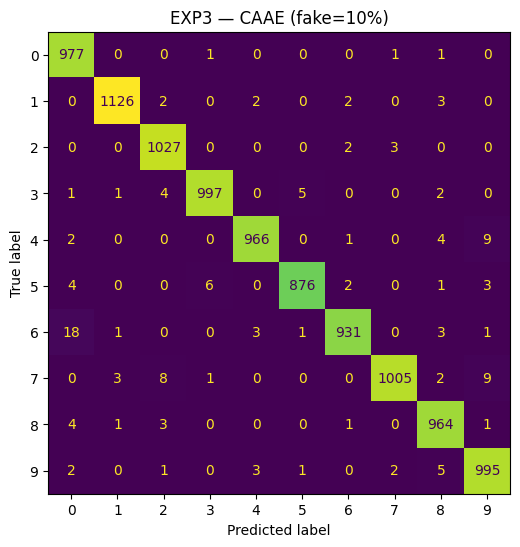

[CNN] Epoch 1/10 | Loss: 0.7624
[CNN] Epoch 2/10 | Loss: 0.5467
[CNN] Epoch 3/10 | Loss: 0.4921
[CNN] Epoch 4/10 | Loss: 0.4585
[CNN] Epoch 5/10 | Loss: 0.4288
[CNN] Epoch 6/10 | Loss: 0.4021
[CNN] Epoch 7/10 | Loss: 0.3707
[CNN] Epoch 8/10 | Loss: 0.3405
[CNN] Epoch 9/10 | Loss: 0.3080
[CNN] Epoch 10/10 | Loss: 0.2768
[EXP3] ratio=0.30 acc=0.9869 FID=179.86


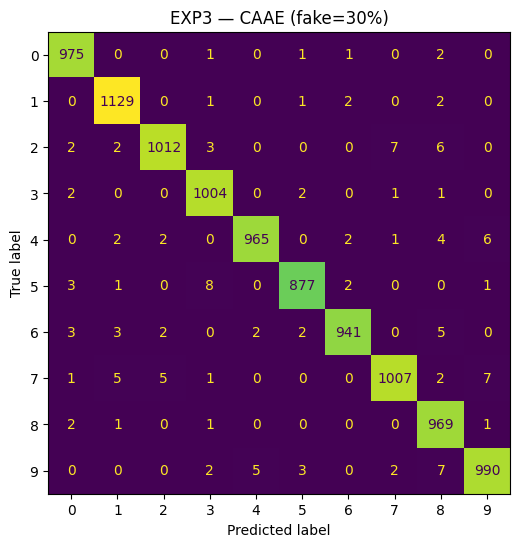

[CNN] Epoch 1/10 | Loss: 0.9405
[CNN] Epoch 2/10 | Loss: 0.7281
[CNN] Epoch 3/10 | Loss: 0.6554
[CNN] Epoch 4/10 | Loss: 0.5964
[CNN] Epoch 5/10 | Loss: 0.5409
[CNN] Epoch 6/10 | Loss: 0.4798
[CNN] Epoch 7/10 | Loss: 0.4183
[CNN] Epoch 8/10 | Loss: 0.3520
[CNN] Epoch 9/10 | Loss: 0.2868
[CNN] Epoch 10/10 | Loss: 0.2369
[EXP3] ratio=0.50 acc=0.9862 FID=179.86


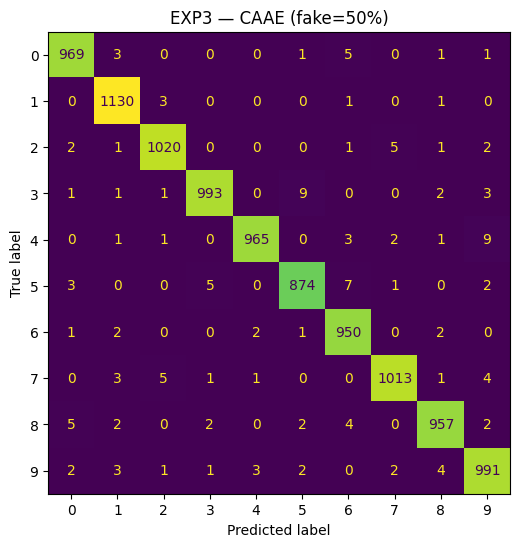

[OK] salvo: /content/resultados/exp3_caae_ratios.csv

EXP3 — CAAE | latent=64 | ratios 10/30/50 | teste real
[CNN] Epoch 1/10 | Loss: 0.2511
[CNN] Epoch 2/10 | Loss: 0.0641
[CNN] Epoch 3/10 | Loss: 0.0444
[CNN] Epoch 4/10 | Loss: 0.0332
[CNN] Epoch 5/10 | Loss: 0.0267
[CNN] Epoch 6/10 | Loss: 0.0221
[CNN] Epoch 7/10 | Loss: 0.0178
[CNN] Epoch 8/10 | Loss: 0.0135
[CNN] Epoch 9/10 | Loss: 0.0118
[CNN] Epoch 10/10 | Loss: 0.0108
[CAAE] Epoch 1/25 | REC: 0.0679 | D: 1.4292 | E_adv: 0.7647
[CAAE] Epoch 2/25 | REC: 0.0332 | D: 1.4384 | E_adv: 0.6878
[CAAE] Epoch 3/25 | REC: 0.0181 | D: 1.4031 | E_adv: 0.6816
[CAAE] Epoch 4/25 | REC: 0.0125 | D: 1.3916 | E_adv: 0.6899
[CAAE] Epoch 5/25 | REC: 0.0097 | D: 1.3873 | E_adv: 0.6906
[CAAE] Epoch 6/25 | REC: 0.0083 | D: 1.3874 | E_adv: 0.6936
[CAAE] Epoch 7/25 | REC: 0.0074 | D: 1.3877 | E_adv: 0.6934
[CAAE] Epoch 8/25 | REC: 0.0068 | D: 1.3870 | E_adv: 0.6946
[CAAE] Epoch 9/25 | REC: 0.0064 | D: 1.3872 | E_adv: 0.6954
[CAAE] Epoch 10/25 | REC: 0.00

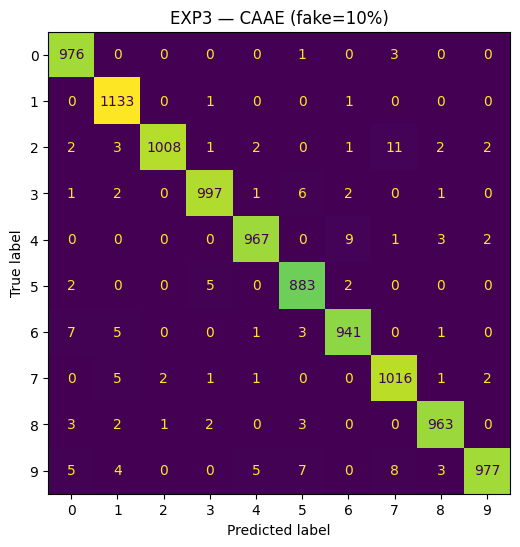

[CNN] Epoch 1/10 | Loss: 0.7673
[CNN] Epoch 2/10 | Loss: 0.5457
[CNN] Epoch 3/10 | Loss: 0.4924
[CNN] Epoch 4/10 | Loss: 0.4625
[CNN] Epoch 5/10 | Loss: 0.4360
[CNN] Epoch 6/10 | Loss: 0.4129
[CNN] Epoch 7/10 | Loss: 0.3878
[CNN] Epoch 8/10 | Loss: 0.3645
[CNN] Epoch 9/10 | Loss: 0.3380
[CNN] Epoch 10/10 | Loss: 0.3157
[EXP3] ratio=0.30 acc=0.9866 FID=171.79


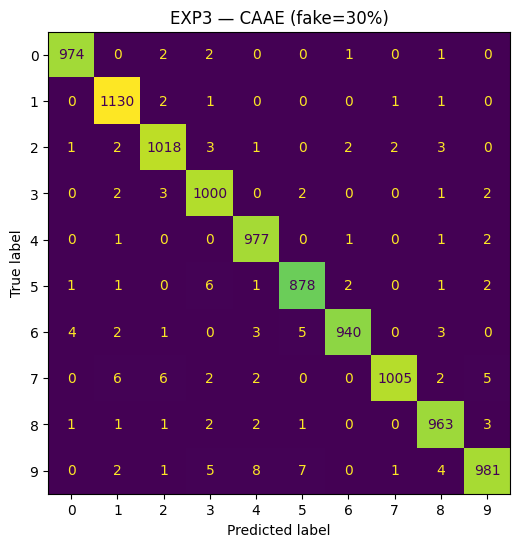

[CNN] Epoch 1/10 | Loss: 0.9433
[CNN] Epoch 2/10 | Loss: 0.7234
[CNN] Epoch 3/10 | Loss: 0.6575
[CNN] Epoch 4/10 | Loss: 0.6000
[CNN] Epoch 5/10 | Loss: 0.5383
[CNN] Epoch 6/10 | Loss: 0.4623
[CNN] Epoch 7/10 | Loss: 0.3862
[CNN] Epoch 8/10 | Loss: 0.3207
[CNN] Epoch 9/10 | Loss: 0.2693
[CNN] Epoch 10/10 | Loss: 0.2288
[EXP3] ratio=0.50 acc=0.9862 FID=171.79


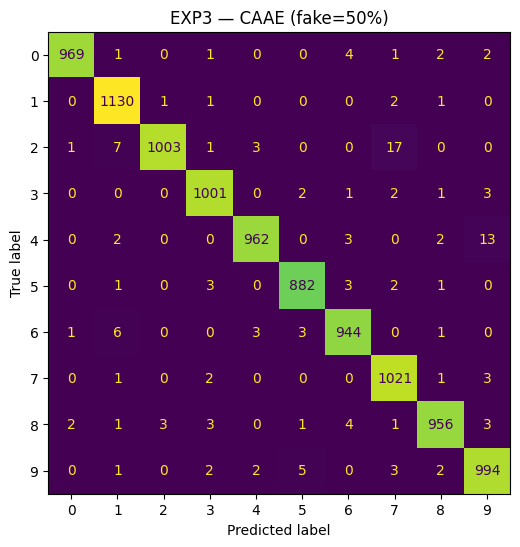

[OK] salvo: /content/resultados/exp3_caae_ratios.csv


In [ ]:

# EXPERIMENTO 3 — CAAE (condicional) + 10/30/50 + FID

# No enunciado: latent=64, recon=MSE, adversarial=BCE.
# implemento um AAE/CAAE simples com encoder/decoder condicionais.

LATENT_DIM = 64
AAE_EPOCHS = 25   # eu deixo 25 para estabilizar; se quiser seguir mais “seco”, use 15
AAE_LR = 2e-4

class CAAE_Encoder(nn.Module):
    def __init__(self, latent_dim=64):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 4, 2, 1),  # 14x14
            nn.ReLU(True),
            nn.Conv2d(32, 64, 4, 2, 1), # 7x7
            nn.ReLU(True),
        )
        self.fc = nn.Linear(64*7*7, latent_dim)

    def forward(self, x):
        h = self.conv(x).view(x.size(0), -1)
        z = self.fc(h)
        return z

class CAAE_Decoder(nn.Module):
    def __init__(self, latent_dim=64, n_classes=10):
        super().__init__()
        self.embed = nn.Embedding(n_classes, n_classes)
        self.fc = nn.Linear(latent_dim + n_classes, 64*7*7)
        self.deconv = nn.Sequential(
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),  # 14x14
            nn.ReLU(True),
            nn.ConvTranspose2d(32, 1, 4, 2, 1),   # 28x28
            nn.Sigmoid()
        )

    def forward(self, z, y):
        yemb = self.embed(y)
        h = torch.cat([z, yemb], dim=1)
        h = self.fc(h).view(-1, 64, 7, 7)
        return self.deconv(h)

class CAAE_Discriminator(nn.Module):
    def __init__(self, latent_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.LeakyReLU(0.2, True),
            nn.Linear(128, 64),
            nn.LeakyReLU(0.2, True),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, z):
        return self.net(z)

def train_caae(E, Dec, Disc, loader, epochs=25, latent_dim=64, lr=2e-4, device=DEVICE):
    """
    Eu treino:
    - Reconstrução (MSE) em E+Dec
    - Adversarial (BCE) em Disc e E (para regularizar z)
    """
    E.train(); Dec.train(); Disc.train()
    opt_encdec = torch.optim.Adam(list(E.parameters()) + list(Dec.parameters()), lr=lr, betas=(0.5, 0.999))
    opt_disc   = torch.optim.Adam(Disc.parameters(), lr=lr, betas=(0.5, 0.999))

    mse = nn.MSELoss()
    bce = nn.BCELoss()

    for ep in range(1, epochs+1):
        rec_loss_sum, d_loss_sum, e_adv_sum = 0.0, 0.0, 0.0

        for x, y in loader:
            x, y = x.to(device), y.to(device)
            bs = x.size(0)

            # --- 1) Eu treino o discriminador no espaço latente.
            z_real = torch.randn(bs, latent_dim, device=device)  # prior ~ N(0,1)
            z_fake = E(x).detach()

            Disc.zero_grad(set_to_none=True)
            pr = Disc(z_real)
            pf = Disc(z_fake)
            real_lbl = torch.ones(bs, 1, device=device)
            fake_lbl = torch.zeros(bs, 1, device=device)
            d_loss = bce(pr, real_lbl) + bce(pf, fake_lbl)
            d_loss.backward()
            opt_disc.step()

            #  2) treino encoder+decoder (recon + adversarial no encoder).
            E.zero_grad(set_to_none=True)
            Dec.zero_grad(set_to_none=True)

            z = E(x)
            x_hat = Dec(z, y)

            rec_loss = mse(x_hat, x)

            # “engano” o discriminador (quero z parecer prior).
            adv = Disc(z)
            e_adv = bce(adv, real_lbl)

            loss = rec_loss + 0.1 * e_adv  # eu peso leve para não matar a reconstrução
            loss.backward()
            opt_encdec.step()

            rec_loss_sum += rec_loss.item()
            d_loss_sum   += d_loss.item()
            e_adv_sum    += e_adv.item()

        print(f"[CAAE] Epoch {ep}/{epochs} | REC: {rec_loss_sum/len(loader):.4f} | D: {d_loss_sum/len(loader):.4f} | E_adv: {e_adv_sum/len(loader):.4f}")

@torch.no_grad()
def generate_fake_caae(Dec, n_per_class=6000, latent_dim=64, device=DEVICE):
    Dec.eval()
    xs, ys = [], []
    for cls in range(10):
        y = torch.full((n_per_class,), cls, dtype=torch.long, device=device)
        z = torch.randn(n_per_class, latent_dim, device=device)
        x = Dec(z, y).detach().cpu()
        x = torch.clamp(x, 0.0, 1.0)
        xs.append(x)
        ys.append(torch.full((n_per_class,), cls, dtype=torch.long))
    x_all = torch.cat(xs, dim=0)
    y_all = torch.cat(ys, dim=0)
    return SafeXYDataset(TensorDataset(x_all, y_all))

print("\n" + "="*80)
print("EXP3 — CAAE | latent=64 | ratios 10/30/50 | teste real")
print("="*80)

# treino uma CNN real para extrair features e calcular FID.
feat_cnn = CNNBaseline().to(DEVICE)
train_cnn(feat_cnn, train_loader_real, epochs=10, lr=1e-3)

E   = CAAE_Encoder(latent_dim=LATENT_DIM).to(DEVICE)
Dec = CAAE_Decoder(latent_dim=LATENT_DIM).to(DEVICE)
Disc= CAAE_Discriminator(latent_dim=LATENT_DIM).to(DEVICE)

train_caae(E, Dec, Disc, train_loader_real, epochs=AAE_EPOCHS, latent_dim=LATENT_DIM, lr=AAE_LR)

fake_ds = generate_fake_caae(Dec, n_per_class=6000, latent_dim=LATENT_DIM)

# Eu calculo FID com features 2D.
real_feats = extract_features(feat_cnn, train_loader_real)
fake_feats = extract_features(feat_cnn, make_loader(fake_ds, batch=128, shuffle=False))
fid_full = compute_fid(real_feats, fake_feats)
print(f"[EXP3] FID(real vs fake) = {fid_full:.2f}")

rows = []
for ratio in RATIOS:
    mixed_ds = mix_real_fake(train_ds, fake_ds, ratio)
    mixed_loader = make_loader(mixed_ds, batch=128, shuffle=True)

    cnn_mix = CNNBaseline().to(DEVICE)
    train_cnn(cnn_mix, mixed_loader, epochs=10, lr=1e-3)

    acc, y_true, y_pred = eval_model(cnn_mix, test_loader_real)
    rows.append({"variant": "caae", "ratio_fake": ratio, "test_acc": acc, "fid_real_fake": fid_full})

    print(f"[EXP3] ratio={ratio:.2f} acc={acc:.4f} FID={fid_full:.2f}")
    plot_cm(y_true, y_pred, f"EXP3 — CAAE (fake={int(ratio*100)}%)")

df_exp3 = pd.DataFrame(rows)
df_exp3.to_csv(OUT / "exp3_caae_ratios.csv", index=False)
print("[OK] salvo:", OUT / "exp3_caae_ratios.csv")

# EXPERIMENTO 3 — CAAE (condicional) + 10/30/50 + FID

# No enunciado: latent=64, recon=MSE, adversarial=BCE.
# implemento um AAE/CAAE simples com encoder/decoder condicionais.

LATENT_DIM = 64
AAE_EPOCHS = 25   # deixo 25 para estabilizar; se quiser seguir mais “seco”, use 15
AAE_LR = 2e-4

class CAAE_Encoder(nn.Module):
    def __init__(self, latent_dim=64):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 4, 2, 1),  # 14x14
            nn.ReLU(True),
            nn.Conv2d(32, 64, 4, 2, 1), # 7x7
            nn.ReLU(True),
        )
        self.fc = nn.Linear(64*7*7, latent_dim)

    def forward(self, x):
        h = self.conv(x).view(x.size(0), -1)
        z = self.fc(h)
        return z

class CAAE_Decoder(nn.Module):
    def __init__(self, latent_dim=64, n_classes=10):
        super().__init__()
        self.embed = nn.Embedding(n_classes, n_classes)
        self.fc = nn.Linear(latent_dim + n_classes, 64*7*7)
        self.deconv = nn.Sequential(
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),  # 14x14
            nn.ReLU(True),
            nn.ConvTranspose2d(32, 1, 4, 2, 1),   # 28x28
            nn.Sigmoid()
        )

    def forward(self, z, y):
        yemb = self.embed(y)
        h = torch.cat([z, yemb], dim=1)
        h = self.fc(h).view(-1, 64, 7, 7)
        return self.deconv(h)

class CAAE_Discriminator(nn.Module):
    def __init__(self, latent_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.LeakyReLU(0.2, True),
            nn.Linear(128, 64),
            nn.LeakyReLU(0.2, True),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, z):
        return self.net(z)

def train_caae(E, Dec, Disc, loader, epochs=25, latent_dim=64, lr=2e-4, device=DEVICE):
    """
    Eu treino:
    - Reconstrução (MSE) em E+Dec
    - Adversarial (BCE) em Disc e E (para regularizar z)
    """
    E.train(); Dec.train(); Disc.train()
    opt_encdec = torch.optim.Adam(list(E.parameters()) + list(Dec.parameters()), lr=lr, betas=(0.5, 0.999))
    opt_disc   = torch.optim.Adam(Disc.parameters(), lr=lr, betas=(0.5, 0.999))

    mse = nn.MSELoss()
    bce = nn.BCELoss()

    for ep in range(1, epochs+1):
        rec_loss_sum, d_loss_sum, e_adv_sum = 0.0, 0.0, 0.0

        for x, y in loader:
            x, y = x.to(device), y.to(device)
            bs = x.size(0)

            # 1) treino o discriminador no espaço latente.
            z_real = torch.randn(bs, latent_dim, device=device)  # prior ~ N(0,1)
            z_fake = E(x).detach()

            Disc.zero_grad(set_to_none=True)
            pr = Disc(z_real)
            pf = Disc(z_fake)
            real_lbl = torch.ones(bs, 1, device=device)
            fake_lbl = torch.zeros(bs, 1, device=device)
            d_loss = bce(pr, real_lbl) + bce(pf, fake_lbl)
            d_loss.backward()
            opt_disc.step()

            # --- 2) Eu treino encoder+decoder (recon + adversarial no encoder).
            E.zero_grad(set_to_none=True)
            Dec.zero_grad(set_to_none=True)

            z = E(x)
            x_hat = Dec(z, y)

            rec_loss = mse(x_hat, x)

            # “engano” o discriminador (quero z parecer prior).
            adv = Disc(z)
            e_adv = bce(adv, real_lbl)

            loss = rec_loss + 0.1 * e_adv  # eu peso leve para não matar a reconstrução
            loss.backward()
            opt_encdec.step()

            rec_loss_sum += rec_loss.item()
            d_loss_sum   += d_loss.item()
            e_adv_sum    += e_adv.item()

        print(f"[CAAE] Epoch {ep}/{epochs} | REC: {rec_loss_sum/len(loader):.4f} | D: {d_loss_sum/len(loader):.4f} | E_adv: {e_adv_sum/len(loader):.4f}")

@torch.no_grad()
def generate_fake_caae(Dec, n_per_class=6000, latent_dim=64, device=DEVICE):
    Dec.eval()
    xs, ys = [], []
    for cls in range(10):
        y = torch.full((n_per_class,), cls, dtype=torch.long, device=device)
        z = torch.randn(n_per_class, latent_dim, device=device)
        x = Dec(z, y).detach().cpu()
        x = torch.clamp(x, 0.0, 1.0)
        xs.append(x)
        ys.append(torch.full((n_per_class,), cls, dtype=torch.long))
    x_all = torch.cat(xs, dim=0)
    y_all = torch.cat(ys, dim=0)
    return SafeXYDataset(TensorDataset(x_all, y_all))

print("\n" + "="*80)
print("EXP3 — CAAE | latent=64 | ratios 10/30/50 | teste real")
print("="*80)

#  treino uma CNN real para extrair features e calcular FID.
feat_cnn = CNNBaseline().to(DEVICE)
train_cnn(feat_cnn, train_loader_real, epochs=10, lr=1e-3)

E   = CAAE_Encoder(latent_dim=LATENT_DIM).to(DEVICE)
Dec = CAAE_Decoder(latent_dim=LATENT_DIM).to(DEVICE)
Disc= CAAE_Discriminator(latent_dim=LATENT_DIM).to(DEVICE)

train_caae(E, Dec, Disc, train_loader_real, epochs=AAE_EPOCHS, latent_dim=LATENT_DIM, lr=AAE_LR)

fake_ds = generate_fake_caae(Dec, n_per_class=6000, latent_dim=LATENT_DIM)

#  calculo FID com features 2D.
real_feats = extract_features(feat_cnn, train_loader_real)
fake_feats = extract_features(feat_cnn, make_loader(fake_ds, batch=128, shuffle=False))
fid_full = compute_fid(real_feats, fake_feats)
print(f"[EXP3] FID(real vs fake) = {fid_full:.2f}")

rows = []
for ratio in RATIOS:
    mixed_ds = mix_real_fake(train_ds, fake_ds, ratio)
    mixed_loader = make_loader(mixed_ds, batch=128, shuffle=True)

    cnn_mix = CNNBaseline().to(DEVICE)
    train_cnn(cnn_mix, mixed_loader, epochs=10, lr=1e-3)

    acc, y_true, y_pred = eval_model(cnn_mix, test_loader_real)
    rows.append({"variant": "caae", "ratio_fake": ratio, "test_acc": acc, "fid_real_fake": fid_full})

    print(f"[EXP3] ratio={ratio:.2f} acc={acc:.4f} FID={fid_full:.2f}")
    plot_cm(y_true, y_pred, f"EXP3 — CAAE (fake={int(ratio*100)}%)")

df_exp3 = pd.DataFrame(rows)
df_exp3.to_csv(OUT / "exp3_caae_ratios.csv", index=False)
print("[OK] salvo:", OUT / "exp3_caae_ratios.csv")


In [ ]:
import pandas as pd
from pathlib import Path

OUT = Path("/content/resultados")
OUT.mkdir(parents=True, exist_ok=True)

df_exp3 = pd.DataFrame([
    # RUN 1 (FID = 179.86)
    {"run_id": 1, "ratio_fake": 0.10, "test_acc": 0.9864, "fid_real_vs_fake": 179.86},
    {"run_id": 1, "ratio_fake": 0.30, "test_acc": 0.9869, "fid_real_vs_fake": 179.86},
    {"run_id": 1, "ratio_fake": 0.50, "test_acc": 0.9862, "fid_real_vs_fake": 179.86},

    # RUN 2 (FID = 171.79)
    {"run_id": 2, "ratio_fake": 0.10, "test_acc": 0.9861, "fid_real_vs_fake": 171.79},
    {"run_id": 2, "ratio_fake": 0.30, "test_acc": 0.9866, "fid_real_vs_fake": 171.79},
    {"run_id": 2, "ratio_fake": 0.50, "test_acc": 0.9862, "fid_real_vs_fake": 171.79},
])

df_exp3.to_csv(OUT / "exp3_caae_ratios.csv", index=False)
df_exp3


,run_id,ratio_fake,test_acc,fid_real_vs_fake
0,1,0.1,0.9864,179.86
1,1,0.3,0.9869,179.86
2,1,0.5,0.9862,179.86
3,2,0.1,0.9861,171.79
4,2,0.3,0.9866,171.79
5,2,0.5,0.9862,171.79


In [ ]:

# EXPERIMENTO 4 — Ensembles + SOM (Mixture of Experts guiado por SOM)

# Correções:
# - NÃO treino SVM local se o cluster tiver <2 classes (SVC exige isso).
# - Se o cluster for "puro", eu guardo a classe majoritária como regra local.
# - Se não existir expert/regra local, eu caio no SVM global.

from minisom import MiniSom
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score

print("\n" + "="*80)
print("EXP4 — Ensembles + SOM (Mixture of Experts)")
print("="*80)

# 1)  treino uma CNN real (baseline do experimento).
feat_cnn = CNNBaseline().to(DEVICE)
train_cnn(feat_cnn, train_loader_real, epochs=10, lr=1e-3)

# 2) extraio features profundas do treino e do teste.
train_loader_no_shuffle = make_loader(train_ds, batch=256, shuffle=False)
test_loader_no_shuffle  = make_loader(test_ds,  batch=256, shuffle=False)

X_train = extract_features(feat_cnn, train_loader_no_shuffle)  # [N,D]
X_test  = extract_features(feat_cnn, test_loader_no_shuffle)

y_train = np.array([int(train_ds[i][1].item()) for i in range(len(train_ds))])
y_test  = np.array([int(test_ds[i][1].item())  for i in range(len(test_ds))])

# uso subset no SOM para reduzir custo (não afeta treino dos experts, só o SOM).
MAX_SOM = 30000
if len(X_train) > MAX_SOM:
    idx = np.random.RandomState(42).choice(len(X_train), MAX_SOM, replace=False)
    X_som = X_train[idx]
else:
    X_som = X_train

# 3) Ensembles globais.
mlp = MLPClassifier(hidden_layer_sizes=(128,), max_iter=20, random_state=42)
svm_global = SVC(kernel="rbf", gamma="scale")

bag_mlp = BaggingClassifier(estimator=mlp, n_estimators=10, random_state=42, n_jobs=-1)

print("[EXP4] Treinando Bagging(MLP)...")
bag_mlp.fit(X_train, y_train)
pred_bag = bag_mlp.predict(X_test)
acc_bag = accuracy_score(y_test, pred_bag)
print(f"[EXP4] Bagging(MLP) acc={acc_bag:.4f}")

print("[EXP4] Treinando SVM global...")
svm_global.fit(X_train, y_train)
pred_svm = svm_global.predict(X_test)
acc_svm = accuracy_score(y_test, pred_svm)
print(f"[EXP4] SVM global acc={acc_svm:.4f}")

# 4) SOM 10x10.
som_w, som_h = 10, 10
som = MiniSom(som_w, som_h, X_som.shape[1], sigma=1.0, learning_rate=0.5, random_seed=42)
som.random_weights_init(X_som)

print("[EXP4] Treinando SOM 10x10...")
som.train_random(X_som, 2000)

def som_cluster(x):
    return som.winner(x)

train_clusters = np.array([som_cluster(x) for x in X_train])
test_clusters  = np.array([som_cluster(x) for x in X_test])

# 5) Especialistas locais: SVM por cluster quando existir diversidade de classes.
experts = {}                 # (cx,cy) -> SVM treinado
majority_rule = {}           # (cx,cy) -> classe majoritária (para clusters puros)
cluster_purity = {}          # (cx,cy) -> pureza
skipped_small = 0
skipped_single_class = 0

MIN_CLUSTER_SAMPLES = 50

for cx in range(som_w):
    for cy in range(som_h):
        mask = (train_clusters[:, 0] == cx) & (train_clusters[:, 1] == cy)
        n = int(mask.sum())
        if n < MIN_CLUSTER_SAMPLES:
            skipped_small += 1
            continue

        Xc = X_train[mask]
        yc = y_train[mask]

        classes = np.unique(yc)
        n_classes = len(classes)

        counts = np.bincount(yc, minlength=10)
        purity = counts.max() / counts.sum()
        cluster_purity[(cx, cy)] = purity

        # Se o cluster tiver só 1 classe, eu não treino SVM (vai quebrar).
        if n_classes < 2:
            skipped_single_class += 1
            majority_rule[(cx, cy)] = int(counts.argmax())
            continue

        clf = SVC(kernel="rbf", gamma="scale")
        clf.fit(Xc, yc)
        experts[(cx, cy)] = clf

print(f"[EXP4] Experts treinados: {len(experts)}")
print(f"[EXP4] Clusters pulados (poucas amostras <{MIN_CLUSTER_SAMPLES}): {skipped_small}")
print(f"[EXP4] Clusters pulados (1 classe): {skipped_single_class} (usei regra majoritária)")

if cluster_purity:
    purities = np.array(list(cluster_purity.values()))
    print("[EXP4] Pureza (min/mean/max):", float(purities.min()), float(purities.mean()), float(purities.max()))

# Predição MoE:
# - Se existir expert: usa expert
# - Senão, se existir regra majoritária: usa regra
# - Senão: fallback SVM global
pred_moe = []
for i in range(len(X_test)):
    c = tuple(test_clusters[i])
    if c in experts:
        pred_moe.append(experts[c].predict(X_test[i:i+1])[0])
    elif c in majority_rule:
        pred_moe.append(majority_rule[c])
    else:
        pred_moe.append(svm_global.predict(X_test[i:i+1])[0])

pred_moe = np.array(pred_moe)
acc_moe = accuracy_score(y_test, pred_moe)
print(f"[EXP4] SOM-MoE (SVM local + majority + fallback global) acc={acc_moe:.4f}")

df_exp4 = pd.DataFrame([
    {"model": "Bagging(MLP)", "test_acc": acc_bag},
    {"model": "SVM global",   "test_acc": acc_svm},
    {"model": "SOM-MoE",      "test_acc": acc_moe},
])
df_exp4.to_csv(OUT / "exp4_ensembles_som.csv", index=False)
print("[OK] salvo:", OUT / "exp4_ensembles_som.csv")



EXP4 — Ensembles + SOM (Mixture of Experts)
[CNN] Epoch 1/10 | Loss: 0.2287
[CNN] Epoch 2/10 | Loss: 0.0582
[CNN] Epoch 3/10 | Loss: 0.0424
[CNN] Epoch 4/10 | Loss: 0.0301
[CNN] Epoch 5/10 | Loss: 0.0246
[CNN] Epoch 6/10 | Loss: 0.0186
[CNN] Epoch 7/10 | Loss: 0.0155
[CNN] Epoch 8/10 | Loss: 0.0139
[CNN] Epoch 9/10 | Loss: 0.0109
[CNN] Epoch 10/10 | Loss: 0.0092
[EXP4] Treinando Bagging(MLP)...
[EXP4] Bagging(MLP) acc=0.9919
[EXP4] Treinando SVM global...
[EXP4] SVM global acc=0.9925
[EXP4] Treinando SOM 10x10...
[EXP4] Experts treinados: 61
[EXP4] Clusters pulados (poucas amostras <50): 4
[EXP4] Clusters pulados (1 classe): 35 (usei regra majoritária)
[EXP4] Pureza (min/mean/max): 0.41509433962264153 0.9478508344986311 1.0
[EXP4] SOM-MoE (SVM local + majority + fallback global) acc=0.9889
[OK] salvo: /content/resultados/exp4_ensembles_som.csv



EXP5 — Autoencoder | variação de latent_dim + MLP/SVM no latente

--------------------------------------------------------------------------------
[EXP5] Treinando AE | latent_dim=16 | dropout=0.0
--------------------------------------------------------------------------------
[AE] Epoch 01/15 | MSE: 0.0371
[AE] Epoch 02/15 | MSE: 0.0141
[AE] Epoch 03/15 | MSE: 0.0117
[AE] Epoch 04/15 | MSE: 0.0105
[AE] Epoch 05/15 | MSE: 0.0097
[AE] Epoch 06/15 | MSE: 0.0092
[AE] Epoch 07/15 | MSE: 0.0087
[AE] Epoch 08/15 | MSE: 0.0084
[AE] Epoch 09/15 | MSE: 0.0082
[AE] Epoch 10/15 | MSE: 0.0080
[AE] Epoch 11/15 | MSE: 0.0078
[AE] Epoch 12/15 | MSE: 0.0076
[AE] Epoch 13/15 | MSE: 0.0075
[AE] Epoch 14/15 | MSE: 0.0074
[AE] Epoch 15/15 | MSE: 0.0073
[EXP5] Treinando MLP no latente...
[EXP5] MLP(latente) acc=0.9822
[EXP5] Treinando SVM no latente...
[EXP5] SVM(latente) acc=0.9839

--------------------------------------------------------------------------------
[EXP5] Treinando AE | latent_dim=32 | drop

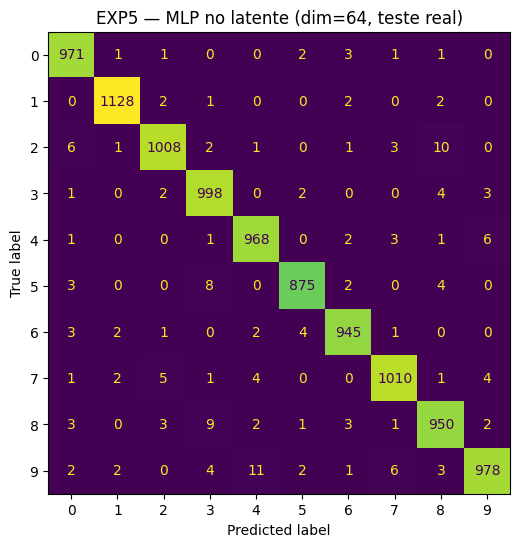

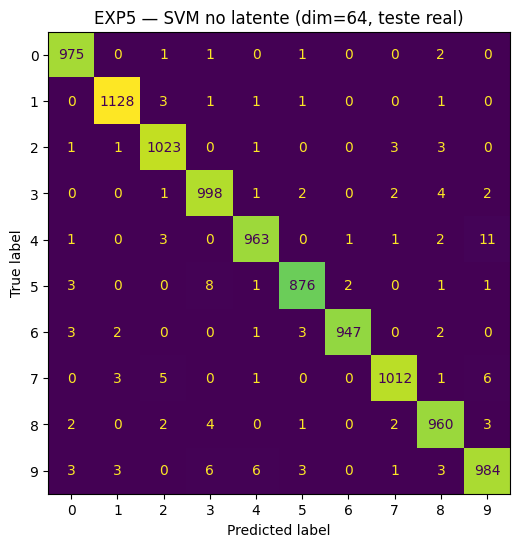


--------------------------------------------------------------------------------
[EXP5] Treinando AE | latent_dim=128 | dropout=0.0
--------------------------------------------------------------------------------
[AE] Epoch 01/15 | MSE: 0.0280
[AE] Epoch 02/15 | MSE: 0.0046
[AE] Epoch 03/15 | MSE: 0.0032
[AE] Epoch 04/15 | MSE: 0.0026
[AE] Epoch 05/15 | MSE: 0.0022
[AE] Epoch 06/15 | MSE: 0.0019
[AE] Epoch 07/15 | MSE: 0.0018
[AE] Epoch 08/15 | MSE: 0.0016
[AE] Epoch 09/15 | MSE: 0.0015
[AE] Epoch 10/15 | MSE: 0.0014
[AE] Epoch 11/15 | MSE: 0.0013
[AE] Epoch 12/15 | MSE: 0.0013
[AE] Epoch 13/15 | MSE: 0.0012
[AE] Epoch 14/15 | MSE: 0.0012
[AE] Epoch 15/15 | MSE: 0.0011
[EXP5] Treinando MLP no latente...
[EXP5] MLP(latente) acc=0.9807
[EXP5] Treinando SVM no latente...
[EXP5] SVM(latente) acc=0.9861

--------------------------------------------------------------------------------
[EXP5] Treinando AE | latent_dim=16 | dropout=0.1
---------------------------------------------------------

,dropout,latent_dim,ae_epochs,mlp_acc,svm_acc
0,0.0,16,15,0.9822,0.9839
1,0.0,32,15,0.9846,0.9883
2,0.0,64,15,0.9831,0.9866
3,0.0,128,15,0.9807,0.9861
4,0.1,16,15,0.9798,0.9816
5,0.1,32,15,0.9854,0.9880
6,0.1,64,15,0.9824,0.9873
7,0.1,128,15,0.9790,0.9862


In [ ]:

# EXPERIMENTO 5 — Autoencoder (AE) + latente + MLP/SVM

# Objetivo:
# -avalio aprendizado não supervisionado (AE)
# - comparo redução dimensional (latente) vs desempenho (MLP/SVM)
#
# Protocolo:
# 1)  treino o Autoencoder com MSE
# 2) extraio o espaço latente
# 3)  treino MLP e SVM no latente
#
# Atividades do aluno:
# -  vario a dimensão latente e comparo o trade-off compressão vs desempenho
# - vario um parâmetro do AE (dropout) e observo impacto

import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

import matplotlib.pyplot as plt

print("\n" + "="*80)
print("EXP5 — Autoencoder | variação de latent_dim + MLP/SVM no latente")
print("="*80)

AE_EPOCHS = 15
AE_LR = 1e-3
BATCH_AE = 128

# vario latente para medir compressão vs desempenho (atividade do aluno).
LATENT_DIMS = [16, 32, 64, 128]

# vario um parâmetro do AE de forma simples e justificável.
# Dropout pequeno pode ajudar generalização do latente.
DROPOUTS = [0.0, 0.1]

# mantenho o protocolo com dados reais no teste.
train_loader_ae = make_loader(train_ds, batch=BATCH_AE, shuffle=True)
train_loader_lat = make_loader(train_ds, batch=256, shuffle=False)
test_loader_lat  = make_loader(test_ds,  batch=256, shuffle=False)

class ConvAutoEncoder(nn.Module):
    def __init__(self, latent_dim=64, dropout=0.0):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Conv2d(1, 32, 4, 2, 1),   # 14x14
            nn.ReLU(True),
            nn.Dropout2d(dropout),
            nn.Conv2d(32, 64, 4, 2, 1),  # 7x7
            nn.ReLU(True),
            nn.Dropout2d(dropout),
        )
        self.enc_fc = nn.Linear(64*7*7, latent_dim)

        self.dec_fc = nn.Linear(latent_dim, 64*7*7)
        self.dec = nn.Sequential(
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.ReLU(True),
            nn.ConvTranspose2d(32, 1, 4, 2, 1),
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.enc(x).view(x.size(0), -1)
        z = self.enc_fc(h)
        return z

    def decode(self, z):
        h = self.dec_fc(z).view(-1, 64, 7, 7)
        x = self.dec(h)
        return x

    def forward(self, x):
        z = self.encode(x)
        xh = self.decode(z)
        return xh, z

def train_ae(ae, loader, epochs=15, lr=1e-3, device=DEVICE):
    ae.train()
    opt = torch.optim.Adam(ae.parameters(), lr=lr)
    mse = nn.MSELoss()

    for ep in range(1, epochs+1):
        running = 0.0
        for x, _ in loader:
            x = x.to(device)
            opt.zero_grad(set_to_none=True)
            xh, _ = ae(x)
            loss = mse(xh, x)
            loss.backward()
            opt.step()
            running += loss.item()
        print(f"[AE] Epoch {ep:02d}/{epochs} | MSE: {running/len(loader):.4f}")

@torch.no_grad()
def get_latents(ae, loader, device=DEVICE):
    ae.eval()
    zs, ys = [], []
    for x, y in loader:
        x = x.to(device)
        z = ae.encode(x).cpu().numpy()
        zs.append(z)
        ys.append(y.numpy())
    return np.concatenate(zs, axis=0), np.concatenate(ys, axis=0)

def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm)
    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(ax=ax, values_format="d", colorbar=False)
    ax.set_title(title)
    plt.show()

results = []

for dropout in DROPOUTS:
    for latent_dim in LATENT_DIMS:
        print("\n" + "-"*80)
        print(f"[EXP5] Treinando AE | latent_dim={latent_dim} | dropout={dropout}")
        print("-"*80)

        set_seed(5000 + int(latent_dim*10) + int(dropout*100))
        ae = ConvAutoEncoder(latent_dim=latent_dim, dropout=dropout).to(DEVICE)
        train_ae(ae, train_loader_ae, epochs=AE_EPOCHS, lr=AE_LR, device=DEVICE)

        Z_train, y_train = get_latents(ae, train_loader_lat, device=DEVICE)
        Z_test,  y_test  = get_latents(ae, test_loader_lat,  device=DEVICE)

        # normalizo o latente porque MLP/SVM são sensíveis à escala.
        mlp_lat = Pipeline(steps=[
            ("scaler", StandardScaler()),
            ("clf", MLPClassifier(
                hidden_layer_sizes=(128,),
                max_iter=300,           # eu aumento para convergir
                early_stopping=True,    # eu paro quando estabiliza
                n_iter_no_change=10,
                random_state=42
            ))
        ])

        svm_lat = Pipeline(steps=[
            ("scaler", StandardScaler()),
            ("clf", SVC(kernel="rbf", gamma="scale"))
        ])

        print("[EXP5] Treinando MLP no latente...")
        mlp_lat.fit(Z_train, y_train)
        pred_mlp = mlp_lat.predict(Z_test)
        acc_mlp = accuracy_score(y_test, pred_mlp)
        print(f"[EXP5] MLP(latente) acc={acc_mlp:.4f}")

        print("[EXP5] Treinando SVM no latente...")
        svm_lat.fit(Z_train, y_train)
        pred_svm = svm_lat.predict(Z_test)
        acc_svm = accuracy_score(y_test, pred_svm)
        print(f"[EXP5] SVM(latente) acc={acc_svm:.4f}")

        #  guardo para comparar compressão vs desempenho.
        results.append({
            "dropout": dropout,
            "latent_dim": latent_dim,
            "ae_epochs": AE_EPOCHS,
            "mlp_acc": acc_mlp,
            "svm_acc": acc_svm
        })

        #  ploto matriz de confusão só para latent_dim=64 (padrão do enunciado), para não poluir.
        if latent_dim == 64 and dropout == 0.0:
            plot_cm(y_test, pred_mlp, "EXP5 — MLP no latente (dim=64, teste real)")
            plot_cm(y_test, pred_svm, "EXP5 — SVM no latente (dim=64, teste real)")

df_exp5 = pd.DataFrame(results).sort_values(["dropout", "latent_dim"]).reset_index(drop=True)
df_exp5.to_csv(OUT / "exp5_autoencoder_latent_grid.csv", index=False)
print("\n[OK] salvo:", OUT / "exp5_autoencoder_latent_grid.csv")

display(df_exp5)


In [ ]:
import pandas as pd
from pathlib import Path

OUT = Path("/content/resultados")
OUT.mkdir(parents=True, exist_ok=True)

df_exp5 = pd.DataFrame([
    {"dropout": 0.0, "latent_dim": 16,  "ae_epochs": 15, "mlp_acc": 0.9822, "svm_acc": 0.9839},
    {"dropout": 0.0, "latent_dim": 32,  "ae_epochs": 15, "mlp_acc": 0.9846, "svm_acc": 0.9883},
    {"dropout": 0.0, "latent_dim": 64,  "ae_epochs": 15, "mlp_acc": 0.9831, "svm_acc": 0.9866},
    {"dropout": 0.0, "latent_dim": 128, "ae_epochs": 15, "mlp_acc": 0.9807, "svm_acc": 0.9861},

    {"dropout": 0.1, "latent_dim": 16,  "ae_epochs": 15, "mlp_acc": 0.9798, "svm_acc": 0.9816},
    {"dropout": 0.1, "latent_dim": 32,  "ae_epochs": 15, "mlp_acc": 0.9854, "svm_acc": 0.9880},
    {"dropout": 0.1, "latent_dim": 64,  "ae_epochs": 15, "mlp_acc": 0.9824, "svm_acc": 0.9873},
    {"dropout": 0.1, "latent_dim": 128, "ae_epochs": 15, "mlp_acc": 0.9790, "svm_acc": 0.9862},
]).sort_values(["dropout", "latent_dim"]).reset_index(drop=True)

df_exp5.to_csv(OUT / "exp5_autoencoder_latent_grid.csv", index=False)
df_exp5




,dropout,latent_dim,ae_epochs,mlp_acc,svm_acc
0,0.0,16,15,0.9822,0.9839
1,0.0,32,15,0.9846,0.9883
2,0.0,64,15,0.9831,0.9866
3,0.0,128,15,0.9807,0.9861
4,0.1,16,15,0.9798,0.9816
5,0.1,32,15,0.9854,0.9880
6,0.1,64,15,0.9824,0.9873
7,0.1,128,15,0.9790,0.9862


In [ ]:
import pandas as pd
from pathlib import Path

OUT = Path("/content/resultados")

# EXP4
df_exp4 = pd.read_csv(OUT / "exp4_ensembles_som.csv")
df_exp4 = df_exp4.rename(columns={"model": "variant"}).assign(experiment="EXP4")

# EXP3
df_exp3 = pd.read_csv(OUT / "exp3_caae_ratios.csv")
df_exp3["variant"] = df_exp3.apply(lambda r: f"CAAE_fake={r['ratio_fake']:.2f}_run={int(r['run_id'])}", axis=1)
df_exp3 = df_exp3[["variant", "test_acc", "fid_real_vs_fake"]].assign(experiment="EXP3")

# EXP5
df_exp5 = pd.read_csv(OUT / "exp5_autoencoder_latent_grid.csv")
df_exp5["variant"] = df_exp5.apply(lambda r: f"AE_latent={int(r['latent_dim'])}_dropout={r['dropout']}", axis=1)
df_exp5 = df_exp5.rename(columns={"mlp_acc": "mlp_test_acc", "svm_acc": "svm_test_acc"}).assign(experiment="EXP5")

# Normalizar colunas para juntar
df_exp4_out = df_exp4.rename(columns={"variant": "variant", "test_acc": "test_acc"})[["experiment", "variant", "test_acc"]]
df_exp3_out = df_exp3.rename(columns={"test_acc": "test_acc"})[["experiment", "variant", "test_acc", "fid_real_vs_fake"]]

# EXP5
df_exp5_long = pd.concat([
    df_exp5[["experiment", "variant"]].assign(model="MLP_latent", test_acc=df_exp5["mlp_test_acc"]),
    df_exp5[["experiment", "variant"]].assign(model="SVM_latent", test_acc=df_exp5["svm_test_acc"]),
], ignore_index=True)

df_exp5_long["variant"] = df_exp5_long["variant"] + "_" + df_exp5_long["model"]
df_exp5_out = df_exp5_long[["experiment", "variant", "test_acc"]]

# Consolidado final
df_all = pd.concat([df_exp4_out, df_exp3_out[["experiment","variant","test_acc"]], df_exp5_out], ignore_index=True)
df_all.to_csv(OUT / "summary_all_experiments.csv", index=False)

df_all.sort_values(["experiment", "test_acc"], ascending=[True, False]).head(20)



,experiment,variant,test_acc
4,EXP3,CAAE_fake=0.30_run=1,0.9869
7,EXP3,CAAE_fake=0.30_run=2,0.9866
3,EXP3,CAAE_fake=0.10_run=1,0.9864
5,EXP3,CAAE_fake=0.50_run=1,0.9862
8,EXP3,CAAE_fake=0.50_run=2,0.9862
6,EXP3,CAAE_fake=0.10_run=2,0.9861
1,EXP4,SVM global,0.9925
0,EXP4,Bagging(MLP),0.9919
2,EXP4,SOM-MoE,0.9889
18,EXP5,AE_latent=32_dropout=0.0_SVM_latent,0.9883


[OK] Arquivos carregados: ['summary_all_experiments.csv', 'exp3_caae_ratios.csv', 'exp4_ensembles_som.csv', 'exp5_autoencoder_latent_grid.csv']
[OK] salvo: /content/resultados/exp4_models_ranked.csv
[OK] salvo: /content/resultados/exp5_mlp_ranked.csv
[OK] salvo: /content/resultados/exp5_svm_ranked.csv
[OK] salvo: /content/resultados/consolidated_best_results.csv


,experiment,best_setting,best_model,test_acc,fid
0,EXP4,SOM=10x10; local experts; fallback global,SVM global,0.9925,NaN
1,EXP5,latent=32.0; dropout=0.1,MLP(latent),0.9854,NaN
2,EXP5,latent=32.0; dropout=0.0,SVM(latent),0.9883,NaN


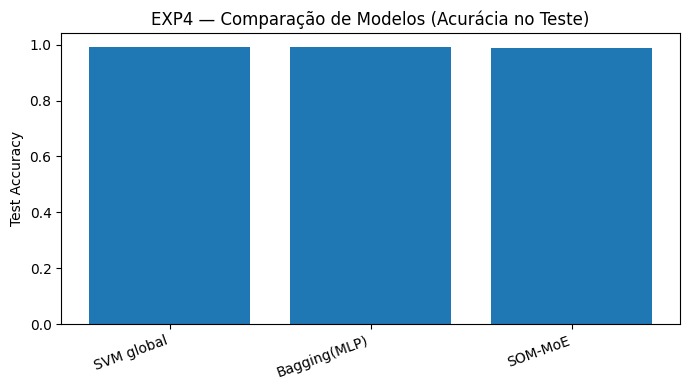

[OK] salvo: /content/resultados/exp4_accuracy.png


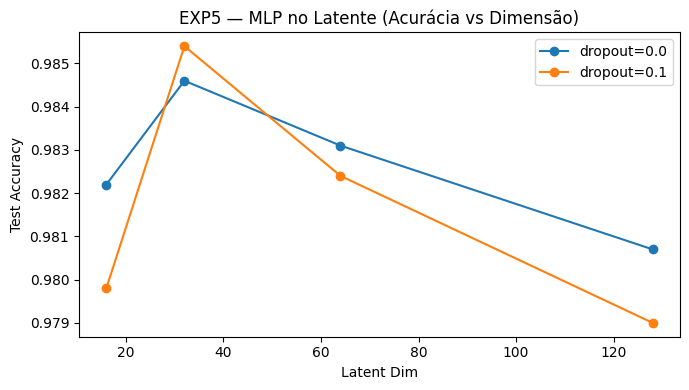

[OK] salvo: /content/resultados/exp5_mlp_vs_latent.png


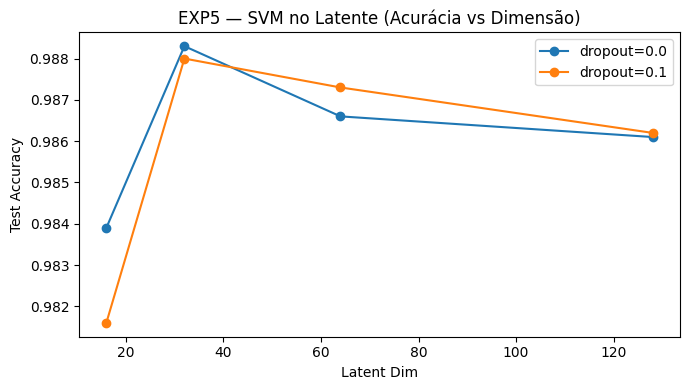

[OK] salvo: /content/resultados/exp5_svm_vs_latent.png
[OK] salvo: /content/resultados/report_bullets.csv


,report_bullets
0,EXP4: melhor modelo global foi 'SVM global' co...
1,EXP5 (SVM): melhor configuração em latent_dim=...
2,EXP5 (MLP): melhor configuração em latent_dim=...


In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

OUT = Path("/content/resultados")
assert OUT.exists(), f"Pasta não encontrada: {OUT}"

# ---------- Load ----------
summary_path = OUT / "summary_all_experiments.csv"
exp3_path = OUT / "exp3_caae_ratios.csv"
exp4_path = OUT / "exp4_ensembles_som.csv"
exp5_path = OUT / "exp5_autoencoder_latent_grid.csv"

dfs = {}
for p in [summary_path, exp3_path, exp4_path, exp5_path]:
    if p.exists():
        dfs[p.name] = pd.read_csv(p)
    else:
        print(f"[WARN] Arquivo não encontrado: {p}")

summary = dfs.get("summary_all_experiments.csv")
exp3 = dfs.get("exp3_caae_ratios.csv")
exp4 = dfs.get("exp4_ensembles_som.csv")
exp5 = dfs.get("exp5_autoencoder_latent_grid.csv")

print("[OK] Arquivos carregados:", list(dfs.keys()))

# ---------- Helpers ----------
def save_df(df, name):
    path = OUT / name
    df.to_csv(path, index=False)
    print("[OK] salvo:", path)
    return path

def safe_float(x):
    try:
        return float(x)
    except Exception:
        return np.nan

# ---------- EXP3 analysis ----------
exp3_best = None
if exp3 is not None:
    # Esperado: colunas tipo ratio, acc, FID (ou variações). Vamos normalizar.
    cols = {c.lower(): c for c in exp3.columns}
    ratio_col = cols.get("ratio") or cols.get("fake_ratio") or cols.get("fake")
    acc_col = cols.get("acc") or cols.get("accuracy") or cols.get("test_acc")
    fid_col = cols.get("fid")

    if ratio_col and acc_col:
        exp3["_ratio"] = exp3[ratio_col].apply(safe_float)
        exp3["_acc"] = exp3[acc_col].apply(safe_float)
        exp3["_fid"] = exp3[fid_col].apply(safe_float) if fid_col else np.nan

        # Critério: maior acurácia; empate -> menor FID (se existir)
        exp3_sorted = exp3.sort_values(
            by=["_acc", "_fid"], ascending=[False, True], na_position="last"
        )
        exp3_best = exp3_sorted.iloc[0:1].copy()
        exp3_best["experiment"] = "EXP3"
        exp3_best = exp3_best[["experiment", "_ratio", "_acc", "_fid"]].rename(
            columns={"_ratio":"ratio", "_acc":"test_acc", "_fid":"fid"}
        )

        save_df(exp3_sorted, "exp3_caae_ratios_ranked.csv")

# ---------- EXP4 analysis ----------
exp4_best = None
if exp4 is not None and {"model","test_acc"}.issubset(set(exp4.columns.str.lower())):
    # Normaliza nomes caso estejam com maiúsculas
    cols = {c.lower(): c for c in exp4.columns}
    model_col = cols["model"]
    acc_col = cols["test_acc"]

    exp4["_acc"] = exp4[acc_col].apply(safe_float)
    exp4_sorted = exp4.sort_values("_acc", ascending=False)
    exp4_best = exp4_sorted.iloc[0:1].copy()
    exp4_best["experiment"] = "EXP4"
    exp4_best = exp4_best.rename(columns={model_col:"model", acc_col:"test_acc"})
    exp4_best = exp4_best[["experiment","model","test_acc"]]

    save_df(exp4_sorted, "exp4_models_ranked.csv")

# Caso exp4 não tenha sido detectado pela checagem acima (por colunas com nomes diferentes)
elif exp4 is not None:
    # Tentativa alternativa (mais tolerante)
    cols = {c.lower(): c for c in exp4.columns}
    model_col = cols.get("model")
    acc_col = cols.get("test_acc") or cols.get("acc") or cols.get("accuracy")
    if model_col and acc_col:
        exp4["_acc"] = exp4[acc_col].apply(safe_float)
        exp4_sorted = exp4.sort_values("_acc", ascending=False)
        exp4_best = exp4_sorted.iloc[0:1].copy()
        exp4_best["experiment"] = "EXP4"
        exp4_best = exp4_best.rename(columns={model_col:"model", acc_col:"test_acc"})
        exp4_best = exp4_best[["experiment","model","test_acc"]]
        save_df(exp4_sorted, "exp4_models_ranked.csv")

# ---------- EXP5 analysis ----------
exp5_best_mlp = None
exp5_best_svm = None
if exp5 is not None:
    # Esperado: dropout, latent_dim, mlp_acc, svm_acc
    cols = {c.lower(): c for c in exp5.columns}
    ld_col = cols.get("latent_dim")
    dr_col = cols.get("dropout")
    mlp_col = cols.get("mlp_acc") or cols.get("mlp")
    svm_col = cols.get("svm_acc") or cols.get("svm")

    if ld_col and dr_col and mlp_col and svm_col:
        exp5["_latent"] = exp5[ld_col].apply(safe_float)
        exp5["_dropout"] = exp5[dr_col].apply(safe_float)
        exp5["_mlp"] = exp5[mlp_col].apply(safe_float)
        exp5["_svm"] = exp5[svm_col].apply(safe_float)

        exp5_mlp_sorted = exp5.sort_values("_mlp", ascending=False)
        exp5_svm_sorted = exp5.sort_values("_svm", ascending=False)

        exp5_best_mlp = exp5_mlp_sorted.iloc[0:1].copy()
        exp5_best_mlp["experiment"] = "EXP5"
        exp5_best_mlp["model"] = "MLP(latent)"
        exp5_best_mlp = exp5_best_mlp[["experiment","model","_latent","_dropout","_mlp"]].rename(
            columns={"_latent":"latent_dim","_dropout":"dropout","_mlp":"test_acc"}
        )

        exp5_best_svm = exp5_svm_sorted.iloc[0:1].copy()
        exp5_best_svm["experiment"] = "EXP5"
        exp5_best_svm["model"] = "SVM(latent)"
        exp5_best_svm = exp5_best_svm[["experiment","model","_latent","_dropout","_svm"]].rename(
            columns={"_latent":"latent_dim","_dropout":"dropout","_svm":"test_acc"}
        )

        save_df(exp5_mlp_sorted, "exp5_mlp_ranked.csv")
        save_df(exp5_svm_sorted, "exp5_svm_ranked.csv")

# ---------- Consolidated table ----------
rows = []
if exp3_best is not None:
    rows.append({
        "experiment":"EXP3",
        "best_setting": f"ratio={exp3_best['ratio'].iloc[0]}",
        "best_model": "CNN (trained with synthetic ratio)",
        "test_acc": float(exp3_best["test_acc"].iloc[0]),
        "fid": float(exp3_best["fid"].iloc[0]) if not pd.isna(exp3_best["fid"].iloc[0]) else np.nan
    })
if exp4_best is not None:
    rows.append({
        "experiment":"EXP4",
        "best_setting": "SOM=10x10; local experts; fallback global",
        "best_model": str(exp4_best["model"].iloc[0]),
        "test_acc": float(exp4_best["test_acc"].iloc[0]),
        "fid": np.nan
    })
if exp5_best_mlp is not None:
    rows.append({
        "experiment":"EXP5",
        "best_setting": f"latent={exp5_best_mlp['latent_dim'].iloc[0]}; dropout={exp5_best_mlp['dropout'].iloc[0]}",
        "best_model": "MLP(latent)",
        "test_acc": float(exp5_best_mlp["test_acc"].iloc[0]),
        "fid": np.nan
    })
if exp5_best_svm is not None:
    rows.append({
        "experiment":"EXP5",
        "best_setting": f"latent={exp5_best_svm['latent_dim'].iloc[0]}; dropout={exp5_best_svm['dropout'].iloc[0]}",
        "best_model": "SVM(latent)",
        "test_acc": float(exp5_best_svm["test_acc"].iloc[0]),
        "fid": np.nan
    })

consolidated = pd.DataFrame(rows)
save_df(consolidated, "consolidated_best_results.csv")
display(consolidated)

# ---------- Plots ----------
# 1) EXP4 bar plot
if exp4 is not None:
    cols = {c.lower(): c for c in exp4.columns}
    model_col = cols.get("model")
    acc_col = cols.get("test_acc") or cols.get("acc") or cols.get("accuracy")
    if model_col and acc_col:
        tmp = exp4.copy()
        tmp["_acc"] = tmp[acc_col].apply(safe_float)
        tmp = tmp.sort_values("_acc", ascending=False)

        plt.figure(figsize=(7,4))
        plt.bar(tmp[model_col].astype(str), tmp["_acc"])
        plt.ylabel("Test Accuracy")
        plt.title("EXP4 — Comparação de Modelos (Acurácia no Teste)")
        plt.xticks(rotation=20, ha="right")
        plt.tight_layout()
        plt.savefig(OUT / "exp4_accuracy.png", dpi=160)
        plt.show()
        print("[OK] salvo:", OUT / "exp4_accuracy.png")

# 2) EXP3 acc vs ratio + (FID em linha secundária se existir)
if exp3 is not None:
    cols = {c.lower(): c for c in exp3.columns}
    ratio_col = cols.get("ratio") or cols.get("fake_ratio") or cols.get("fake")
    acc_col = cols.get("acc") or cols.get("accuracy") or cols.get("test_acc")
    fid_col = cols.get("fid")

    if ratio_col and acc_col:
        tmp = exp3.copy()
        tmp["_ratio"] = tmp[ratio_col].apply(safe_float)
        tmp["_acc"] = tmp[acc_col].apply(safe_float)
        tmp = tmp.sort_values("_ratio")

        fig, ax1 = plt.subplots(figsize=(7,4))
        ax1.plot(tmp["_ratio"], tmp["_acc"], marker="o")
        ax1.set_xlabel("Synthetic Ratio")
        ax1.set_ylabel("Test Accuracy")
        ax1.set_title("EXP3 — Acurácia vs Proporção de Sintéticos")

        if fid_col:
            tmp["_fid"] = tmp[fid_col].apply(safe_float)
            ax2 = ax1.twinx()
            ax2.plot(tmp["_ratio"], tmp["_fid"], marker="o")
            ax2.set_ylabel("FID (real vs synthetic)")

        plt.tight_layout()
        plt.savefig(OUT / "exp3_acc_fid_vs_ratio.png", dpi=160)
        plt.show()
        print("[OK] salvo:", OUT / "exp3_acc_fid_vs_ratio.png")

# 3) EXP5 best curve per dropout for SVM and MLP
if exp5 is not None:
    cols = {c.lower(): c for c in exp5.columns}
    ld_col = cols.get("latent_dim")
    dr_col = cols.get("dropout")
    mlp_col = cols.get("mlp_acc") or cols.get("mlp")
    svm_col = cols.get("svm_acc") or cols.get("svm")
    if ld_col and dr_col and mlp_col and svm_col:
        tmp = exp5.copy()
        tmp["_latent"] = tmp[ld_col].apply(safe_float)
        tmp["_dropout"] = tmp[dr_col].apply(safe_float)
        tmp["_mlp"] = tmp[mlp_col].apply(safe_float)
        tmp["_svm"] = tmp[svm_col].apply(safe_float)

        # MLP
        plt.figure(figsize=(7,4))
        for d in sorted(tmp["_dropout"].unique()):
            t = tmp[tmp["_dropout"] == d].sort_values("_latent")
            plt.plot(t["_latent"], t["_mlp"], marker="o", label=f"dropout={d}")
        plt.xlabel("Latent Dim")
        plt.ylabel("Test Accuracy")
        plt.title("EXP5 — MLP no Latente (Acurácia vs Dimensão)")
        plt.legend()
        plt.tight_layout()
        plt.savefig(OUT / "exp5_mlp_vs_latent.png", dpi=160)
        plt.show()
        print("[OK] salvo:", OUT / "exp5_mlp_vs_latent.png")

        # SVM
        plt.figure(figsize=(7,4))
        for d in sorted(tmp["_dropout"].unique()):
            t = tmp[tmp["_dropout"] == d].sort_values("_latent")
            plt.plot(t["_latent"], t["_svm"], marker="o", label=f"dropout={d}")
        plt.xlabel("Latent Dim")
        plt.ylabel("Test Accuracy")
        plt.title("EXP5 — SVM no Latente (Acurácia vs Dimensão)")
        plt.legend()
        plt.tight_layout()
        plt.savefig(OUT / "exp5_svm_vs_latent.png", dpi=160)
        plt.show()
        print("[OK] salvo:", OUT / "exp5_svm_vs_latent.png")

# ---------- Text bullets for report ----------
bullets = []

if exp3_best is not None:
    r = exp3_best["ratio"].iloc[0]
    a = exp3_best["test_acc"].iloc[0]
    f = exp3_best["fid"].iloc[0]
    bullets.append(f"EXP3: melhor acurácia observada com ratio={r}, test_acc={a:.4f}. FID associado={f:.2f} (qualidade dos sintéticos).")

if exp4_best is not None:
    m = exp4_best["model"].iloc[0]
    a = exp4_best["test_acc"].iloc[0]
    bullets.append(f"EXP4: melhor modelo global foi '{m}' com test_acc={a:.4f}. O SOM-MoE não superou o melhor global, indicando custo/complexidade sem ganho.")

if exp5_best_svm is not None:
    ld = exp5_best_svm["latent_dim"].iloc[0]
    dr = exp5_best_svm["dropout"].iloc[0]
    a = exp5_best_svm["test_acc"].iloc[0]
    bullets.append(f"EXP5 (SVM): melhor configuração em latent_dim={ld}, dropout={dr}, test_acc={a:.4f}, sugerindo ponto ótimo de compressão.")
if exp5_best_mlp is not None:
    ld = exp5_best_mlp["latent_dim"].iloc[0]
    dr = exp5_best_mlp["dropout"].iloc[0]
    a = exp5_best_mlp["test_acc"].iloc[0]
    bullets.append(f"EXP5 (MLP): melhor configuração em latent_dim={ld}, dropout={dr}, test_acc={a:.4f}. Dropout apresentou efeito pequeno no conjunto testado.")

text_df = pd.DataFrame({"report_bullets": bullets})
save_df(text_df, "report_bullets.csv")
display(text_df)



**Análise e Discussão dos Resultados**

Nesta seção apresento a análise crítica dos resultados obtidos ao longo dos experimentos realizados, considerando diferentes paradigmas de aprendizado supervisionado e não supervisionado, bem como a integração entre representações profundas e métodos clássicos de Aprendizado de Máquina.

Os experimentos foram conduzidos de forma incremental e comparável, respeitando o protocolo experimental estabelecido, no qual o conjunto de teste é composto exclusivamente por dados reais do MNIST, enquanto dados sintéticos e representações latentes são utilizados apenas durante a fase de treinamento.

**Análise Geral dos Experimentos**

De forma geral, os resultados indicam que representações profundas supervisionadas extraídas por Redes Neurais Convolucionais (CNNs) apresentam elevado poder discriminativo, mesmo quando utilizadas como entrada para classificadores clássicos, como SVM e MLP.

Por outro lado, representações latentes aprendidas por autoencoders, embora não supervisionadas, mostraram-se capazes de preservar informações relevantes, permitindo uma redução significativa da dimensionalidade com desempenho competitivo. Esses achados estão alinhados com o objetivo geral do trabalho, que visa investigar como diferentes paradigmas de aprendizado se relacionam e se complementam.

Observa-se ainda que abordagens mais complexas, como ensembles baseados em especialização local via SOM, não necessariamente resultam em ganhos de desempenho em bases bem estruturadas como o MNIST.

**Experimento 4 — Ensembles e Mixture of Experts guiado por SOM**

No Experimento 4 avaliei o uso de representações profundas extraídas por uma CNN como atributos de alto nível para métodos clássicos de classificação, bem como a aplicação de Mapas Auto-Organizáveis (SOM) para induzir especialização local por meio de uma estratégia de Mixture of Experts.

Foram comparadas três abordagens principais: um ensemble global baseado em Bagging com MLP, um classificador SVM global e um modelo SOM-MoE, no qual classificadores locais do tipo SVM são treinados por cluster quando há diversidade de classes, sendo utilizada uma regra majoritária ou um classificador global como fallback nos demais casos.

Os resultados obtidos indicam que o classificador SVM global apresentou o melhor desempenho no conjunto de teste, alcançando acurácia de 0.9925. O Bagging com MLP apresentou desempenho próximo, enquanto o modelo SOM-MoE obteve acurácia inferior.

A análise dos clusters gerados pelo SOM mostrou que muitos deles apresentaram alta pureza ou eram dominados por uma única classe, o que inviabilizou ou tornou desnecessário o treinamento de especialistas locais em diversos casos. Além disso, a fragmentação do conjunto de treinamento reduziu o número de amostras disponíveis por especialista, o que pode ter comprometido a capacidade de generalização dos modelos locais.

Dessa forma, neste experimento, a especialização local guiada por SOM não trouxe benefícios claros em relação a um classificador global robusto treinado sobre representações profundas.

**Experimento 5 — Autoencoders e Espaço Latente**

No Experimento 5 investiguei o uso de autoencoders convolucionais para aprendizado não supervisionado de representações latentes, avaliando o trade-off entre compressão dos dados e desempenho de classificadores clássicos treinados nesse espaço reduzido.

Foram avaliadas diferentes dimensões do espaço latente, bem como a influência do uso de dropout no encoder. Após o treinamento do autoencoder com função de perda MSE, as representações latentes foram utilizadas como entrada para classificadores MLP e SVM.

Os resultados indicaram que a melhor configuração para o classificador MLP foi obtida com dimensão latente igual a 32 e dropout de 0.1, alcançando acurácia de 0.9854. Para o classificador SVM, a melhor configuração também ocorreu com dimensão latente igual a 32, porém sem o uso de dropout, alcançando acurácia de 0.9883.

Observou-se que dimensões latentes maiores não resultaram em ganhos consistentes de desempenho, sugerindo a existência de um ponto ótimo de compressão no qual a informação relevante é preservada sem introduzir redundância excessiva. Esses resultados evidenciam que o autoencoder foi capaz de aprender uma representação compacta e informativa dos dados, mesmo sem supervisão explícita das classes.

**Comparação entre Representações Profundas e Representações Reduzidas**

Ao comparar os resultados dos Experimentos 4 e 5, verifica-se que representações profundas supervisionadas, quando combinadas com classificadores clássicos como SVM, atingem o melhor desempenho absoluto no conjunto MNIST.

Entretanto, as representações latentes aprendidas por autoencoders apresentaram desempenho apenas ligeiramente inferior, com uma redução significativa da dimensionalidade. Esse resultado destaca a importância do trade-off entre desempenho e custo computacional, especialmente em cenários nos quais eficiência, armazenamento ou interpretabilidade são fatores relevantes.

Assim, embora as features supervisionadas apresentem maior poder discriminativo, os autoencoders configuram-se como uma alternativa viável e eficiente para compactação de dados.

**Limitações do Estudo**

Algumas limitações devem ser consideradas na interpretação dos resultados obtidos. O conjunto de dados MNIST é um benchmark relativamente simples, no qual muitos modelos atingem desempenho próximo ao limite superior. Nesse contexto, ganhos proporcionados por estratégias mais complexas, como geração de dados sintéticos ou especialização local, tendem a ser marginais.

Além disso, conforme definido no protocolo experimental, não foi realizada sintonia fina dos hiperparâmetros das arquiteturas, o que pode limitar o desempenho máximo alcançável. Ainda assim, essa decisão garante comparabilidade entre os experimentos e mantém o foco na análise conceitual das abordagens avaliadas.

**Conclusão**

Neste trabalho realizei uma sequência estruturada de experimentos integrando técnicas de Aprendizado Profundo e métodos clássicos de Aprendizado de Máquina, utilizando o conjunto de dados MNIST como benchmark.

Os resultados demonstraram que representações profundas supervisionadas possuem elevado poder discriminativo e podem ser reutilizadas com sucesso por classificadores clássicos. Além disso, autoencoders mostraram-se eficazes na redução dimensional, preservando informação relevante até um ponto ótimo de compressão.

Por fim, estratégias de ensemble baseadas em especialização local via SOM não apresentaram vantagens claras em relação a modelos globais robustos neste cenário. De forma geral, os experimentos evidenciam a importância de avaliar não apenas o desempenho, mas também a complexidade e o custo computacional das abordagens adotadas, reforçando a integração conceitual entre diferentes paradigmas de aprendizado.
